# CFRM 521/421 Machine Learning for Finance

**Project Title:**
Volatility Prediction of Microsoft Using Machine Learning

**Group Members:**  
- Jenny Fu (email: jennyfu1@uw.edu, Algorithm: Support Vector Regression)  
- Emma Xu (email: zihanxu@uw.edu, Algorithm: Gradient Boosing)  
- Shawn Wen (email: shaobw@uw.edu, Algorithm: Recurrent Neural Network)  
- Zihan Zhu (email: zihanzhu@uw.edu, Algorithm: Random Forest)  

**Date:**
2026/06/05

# 1. Introduction

## 1.1 Problem Statement
- The objective of this project is to forecast the future stock volatility of Microsoft (MSFT) using historical market data from 2016 to 2026. We investigate whether machine learning models can learn useful patterns from past stock price returns, volatility metrics, trading volume, and broader market indicators to improve the accuracy of volatility forecasts across various time horizons.
- Volatility is one of the most important indicators for measuring financial risk. Accurate volatility prediction helps investors, portfolio managers, and financial institutions make better decisions in areas such as risk management, portfolio allocation, derivative pricing, and hedging strategies. Given that stock volatility is highly dynamic and influenced by various market factors, constructing an effective prediction model remains a significant challenge in the financial field.
- This project focuses on a financial prediction task. We are studying the issue of using historical stock and market data to predict the future volatility of Microsoft (MSFT) stocks. We compared various machine learning methods such as linear regression, random forest, gradient boosting, support vector regression (SVR), Lasso and neural networks, aiming to evaluate their ability to predict future volatility over daily, weekly, and monthly time spans.


## 1.2 Related Literature
- Previous studies on stock volatility prediction have used models such as ARCH and GARCH, which are designed to capture the tendency of volatility to change over time. These models have been widely used in finance because stock market volatility often shows periods of high and low fluctuations. More recently, machine learning methods such as Random Forest, Support Vector Regression (SVR), Gradient Boosting, and Neural Networks have become popular because they can capture more complex relationships between financial variables.

- This project follows this general direction by applying machine learning models to predict future stock volatility. We use ten years of Microsoft (MSFT) stock data together with market indicators such as VIX, SPY, XLK, and other related variables. We compare several machine learning methods, including Random Forest, Gradient Boosting, SVR, and Neural Networks, to see which model performs best. Rather than focusing on a single model, our goal is to compare different approaches and better understand the challenges of predicting stock volatility.

- Cite all sources properly.

## 1.3 Contribution
- This project compares several machine learning methods for predicting stock volatility. Using the same MSFT dataset and feature set, we evaluate the performance of Linear Regression, Random Forest, Gradient Boosting, SVR, and Neural Networks. In addition to historical MSFT stock information, we include market indicators such as VIX, SPY, QQQ, and XLK to provide broader market information.

- Our contribution is mainly an empirical comparison and a new application. We apply several machine learning models to predict MSFT volatility and compare their performance across 1-day, 5-day, and 21-day horizons. We also include broader market and macroeconomic indicators, such as VIX, VXN, SPY, QQQ, XLK, and TNX, instead of only using MSFT historical price data.

# 2. Data Handling

## 2.1 Data Source
The original data for this project comes from Yahoo Finance. We used the Python `yfinance` API to download daily historical market data from January 1, 2016 to January 1, 2026. The main asset is Microsoft stock (`MSFT`), and we also include broader market and financial indicators such as `SPY`, `QQQ`, `XLK`, `^VIX`, `^VXN`, `^TNX`, `SOXX`, and `TLT`.

The data were downloaded using `yf.download()` with `auto_adjust=True`, so the price series are adjusted for corporate actions such as stock splits and dividends. Each observation represents one trading day in the U.S. financial market.









In [6]:
import yfinance as yf

# Load Data from Yahoo Finance
tickers = [
    'MSFT',
    'SPY',
    'QQQ',
    'XLK',
    '^VIX',
    '^VXN',
    '^TNX',
    'SOXX',
    'TLT'
]

data = yf.download(
    tickers,
    start='2016-01-01',
    end='2026-01-01',
    auto_adjust=True
)
data.head()

[*********************100%***********************]  9 of 9 completed


Price           Close                                                \
Ticker           MSFT         QQQ       SOXX         SPY        TLT   
Date                                                                  
2016-01-04  47.770725  101.717285  26.696753  169.908142  90.984589   
2016-01-05  47.988667  101.540764  26.444214  170.195572  90.617531   
2016-01-06  47.116932  100.565430  25.530273  168.048645  91.838585   
2016-01-07  45.478073   97.416374  24.814753  164.016861  92.003418   
2016-01-08  45.617554   96.617477  24.456991  162.216583  92.415459   

Price                                                    High  ...       Open  \
Ticker            XLK   ^TNX       ^VIX       ^VXN       MSFT  ...       ^VXN   
Date                                                           ...              
2016-01-04  18.860451  2.245  20.700001  22.420000  47.770725  ...  19.629999   
2016-01-05  18.811373  2.248  19.340000  21.559999  48.285054  ...  22.440001   
2016-01-06  18.579351  2.177  20.590000  22.480000  47.422039  ...  21.559999   
2016-01-07  18.030542  2.153  24.990000  26.770000  46.628758  ...  22.500000   
2016-01-08  17.887756  2.130  27.010000  28.330000  46.445693  ...  26.879999   

Price         Volume                                                         \
Ticker          MSFT       QQQ     SOXX        SPY       TLT       XLK ^TNX   
Date                                                                          
2016-01-04  53778000  50807600  1023000  222353500  10591900  43277200  0.0   
2016-01-05  34079700  38795200  1329000  110845800   6242600  32134400  0.0   
2016-01-06  39518900  41891100  1541100  152112600   8916900  27716800  0.0   
2016-01-07  56564900  61386300  2026800  213436100  10202200  33681400  0.0   
2016-01-08  48754000  69344000  1465200  209817200   9577200  38466200  0.0   

Price                 
Ticker     ^VIX ^VXN  
Date                  
2016-01-04    0    0  
2016-01-05    0    0  
2016-01-06    0    0  
2016-01-07    0    0  
2016-01-08    0    0  

[5 rows x 45 columns]

## 2.2 Data Structure
Each row represents one trading day. For each day, we collect Microsoft (MSFT) stock prices, trading volume, and several market-related variables, including major market indices (SPY and QQQ), sector ETFs (XLK and SOXX), volatility indices (VIX and VXN), Treasury yield data (TNX), and bond market information (TLT). These variables are subsequently used to construct features for forecasting future MSFT stock volatility.


The dataset covers the period from January 1, 2016, to January 1, 2026, with a daily frequency. After removing observations with missing values generated by feature engineering and rolling-window calculations, the final dataset contains 2,365 observations.

## 2.3 Target Variable
The response variable in this project is the future volatility of Microsoft (MSFT) stock. We measure volatility using the standard deviation of stock returns over a future time period. Specifically, we construct volatility targets for three prediction horizons: 1-day, 5-day, and 21-day volatility.

For each trading day, the models use historical information, such as past MSFT returns, rolling volatility measures, and market indicators (SPY, VIX, QQQ, and XLK), to predict the volatility that will be observed in the future.


## 2.4 Features
We constructed predictors from four main categories of financial information(as indicated in Section 2.5):
1. MSFT Historical Return Features

These features describe Microsoft's recent stock performance using current and lagged log returns. We include returns from the current day as well as returns from 1, 3, 5, 10, 15, and 21 trading days earlier to capture short-term momentum and price movements.

Examples: MSFT_log_return



2. Volatility Features

These features measure historical volatility over different time horizons. Shorter windows (5 and 21 days) capture recent market fluctuations, while longer windows (63 and 126 days) represent medium- and long-term volatility trends.

Examples: MSFT_rolling_vol_5  


3. Market and Sector Features

These features capture broader market and technology-sector conditions that may influence Microsoft stock volatility. They include returns and volatility measures from market ETFs and sector indexes.

Examples: SPY_log_return


4. Volatility Index Features

These features are based on the VIX and VXN volatility indexes. In addition to the current index level, we include daily changes and 21-day moving averages to capture both short-term and longer-term market sentiment.

Examples: VIX_level

5. Trading Activity Features

These features measure trading activity in Microsoft stock. Trading volume may reflect investor attention and market participation, which can be related to future volatility.

Examples: MSFT_log_volume


6. Relative Performance Features

These features compare Microsoft's returns with the broader market or technology sector. They help identify whether Microsoft is outperforming or underperforming its peers.

Examples: MSFT_minus_SPY_return

7. Additional Engineered Features

These features combine information from multiple volatility measures and market events. For example, volatility ratios compare short-term volatility (5 or 21 days) with longer-term volatility (21 or 63 days), while the earnings indicator identifies periods around company earnings announcements.

Examples: vol_ratio_5_21

## 2.5 Data Cleaning and Preprocessing

To improve code organization and readability, all data preprocessing and feature engineering procedures were implemented in a separate helper function, feature_engineering(). This function generates the final modeling dataset, target variables, and selected feature set used throughout the analysis.

In [7]:
# Import Useful Libraries and Support Function
from data_processing import feature_engineering
import numpy as np
import pandas as pd

In [8]:
model_data, feature_cols, target_cols = feature_engineering(data)

/home/jovyan/lost+found/data_processing.py:80: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['TNX_change'] = df['TNX_Close'].pct_change()


In [9]:
print("Model data shape:", model_data.shape)
print("Total number of features:", len(feature_cols))

Model data shape: (2365, 65)
Total number of features: 39


After feature engineering, the dataset contained 39 candidate predictors. Since many financial variables are derived from similar underlying market information, multicollinearity may be present. To identify potential redundancy, we examined pairwise correlations among all engineered features and focused on highly correlated feature pairs.

In [10]:
# Check highly correlated features after removing redundant features
corr_matrix = model_data[feature_cols].corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
).sort_values(by='Correlation', ascending=False)

high_corr_df

,Feature 1,Feature 2,Correlation
8,MSFT_rolling_vol_63,MSFT_vol_63_lag1,0.997747
2,MSFT_rolling_vol_21,MSFT_vol_21_lag1,0.989264
7,VIX_rolling_mean_21,VXN_rolling_mean_21,0.969046
5,VIX_level,VXN_level,0.964111
3,SPY_log_return,XLK_log_return,0.930893
6,VIX_log_change,VXN_log_change,0.912825
1,MSFT_rolling_vol_21,SPY_rolling_vol_21,0.909308
4,SPY_rolling_vol_21,MSFT_vol_21_lag1,0.903306
0,MSFT_rolling_vol_5,MSFT_vol_5_lag1,0.902206


Several feature pairs exhibited extremely high correlations. For example, MSFT rolling volatility measures and their lagged counterparts showed correlations above 0.98. Similarly, VIX and VXN related variables were highly correlated due to their similar roles as market volatility indicators. These results suggest that some predictors may provide overlapping information.

Before applying LASSO feature selection, all predictors were standardized using StandardScaler because the features were measured on different scales. Standardization ensures that the LASSO penalty is applied consistently across variables. LASSO was then used to identify important predictors and remove redundant features, helping to reduce multicollinearity and improve model interpretability.

At the same time, the dataset was divided into training, validation, and testing sets based on chronological order rather than random sampling. Because stock market data are time-series observations, preserving the temporal structure is essential to avoid look-ahead bias. The earliest observations were used for model training, the subsequent observations for validation and hyperparameter tuning, and the most recent observations for out-of-sample testing. This setup better reflects real-world forecasting conditions and ensures a fair evaluation of model performance.

In [11]:
# Time-series train / validation / test split
model_data = model_data.sort_index()

n = len(model_data)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)


train_data = model_data.iloc[:train_end]
valid_data = model_data.iloc[train_end:valid_end]
test_data = model_data.iloc[valid_end:]

print("Total observations:", n)
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("Test shape:", test_data.shape)


# Define X variables
X_train = train_data[feature_cols]
X_valid = valid_data[feature_cols]
X_test = test_data[feature_cols]


# Define y variables
# Daily target
y_train_1d = train_data['target_volatility_1d']
y_valid_1d = valid_data['target_volatility_1d']
y_test_1d = test_data['target_volatility_1d']

# Weekly target
y_train_5d = train_data['target_volatility_5d']
y_valid_5d = valid_data['target_volatility_5d']
y_test_5d = test_data['target_volatility_5d']

# Monthly target
y_train_21d = train_data['target_volatility_21d']
y_valid_21d = valid_data['target_volatility_21d']
y_test_21d = test_data['target_volatility_21d']

Total observations: 2365
Train shape: (1655, 65)
Validation shape: (355, 65)
Test shape: (355, 65)


In [12]:
# Standardization
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    index=X_train.index,
    columns=feature_cols
)

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    index=X_valid.index,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    index=X_test.index,
    columns=feature_cols
)

Applied LASSO Regularization below

In [13]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(
    cv=5,
    random_state=42,
    max_iter=100000
)

lasso.fit(
    X_train_scaled,
    y_train_21d
)

lasso_coef = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": lasso.coef_
})

lasso_coef["AbsCoefficient"] = (
    lasso_coef["Coefficient"].abs()
)

lasso_coef = (
    lasso_coef
    .sort_values(
        by="AbsCoefficient",
        ascending=False
    )
)

print("Best alpha:", lasso.alpha_)
print("Selected features:",
      (lasso_coef["Coefficient"] != 0).sum())

Best alpha: 0.0007079241307961216
Selected features: 5


After applying LASSO regularization, only five features were selected with non-zero coefficients. This suggests that a relatively small subset of variables contains most of the predictive information for future MSFT volatility. Among the selected features, VXN_level and VIX_relative represent market volatility conditions, TNX_level reflects interest rate expectations, MSFT_log_volume captures trading activity, and vol_ratio_21_63 measures changes in volatility across different time horizons. These variables are therefore retained for subsequent model construction.

In [59]:
top5_features = (
    lasso_coef
    .head(5)["Feature"]
    .tolist()
)

print(top5_features)

['VXN_level', 'vol_ratio_21_63', 'VIX_relative', 'MSFT_log_volume', 'TNX_level']


In [65]:
# Features Update Based on Result of LASSO
X_train_scaled = X_train_scaled[top5_features]
X_valid_scaled = X_valid_scaled[top5_features]
X_test_scaled  = X_test_scaled[top5_features]

In [86]:
model_data = model_data[top5_features + target_cols]

In [87]:
model_data.head()

,VXN_level,vol_ratio_21_63,VIX_relative,MSFT_log_volume,TNX_level,target_volatility_1d,target_volatility_5d,target_volatility_21d
Date,,,,,,,,
2016-07-05,17.920000,1.024230,0.860796,17.026612,1.367,0.004095,0.006965,0.013017
2016-07-06,17.490000,1.024649,0.823702,17.153679,1.385,0.000000,0.006792,0.013024
2016-07-07,17.280001,1.028659,0.811180,16.790285,1.387,0.017748,0.005691,0.013003
2016-07-08,15.740000,1.047617,0.727120,17.161583,1.366,0.005530,0.004442,0.012730
2016-07-11,15.110000,1.041935,0.748007,16.918715,1.434,0.011720,0.004444,0.012741


## 2.6 Summary

In this section, we obtained historical market data from Yahoo Finance and performed a series of preprocessing procedures, including feature engineering, data cleaning, feature standardization, and a chronological train-validation-test split. Since the dataset consists of time-series observations, the split was conducted based on time order to avoid look-ahead bias and better reflect real-world forecasting conditions.

After preprocessing, we applied LASSO regularization for feature selection. LASSO helps identify the most informative predictors while reducing multicollinearity and removing redundant variables. From the original set of 39 engineered features, LASSO selected five key predictors that were subsequently used to forecast 1-day, 5-day, and 21-day future volatility, as indicated below.


In [88]:
print(top5_features)

['VXN_level', 'vol_ratio_21_63', 'VIX_relative', 'MSFT_log_volume', 'TNX_level']


### Interpretation of Selected Features

The selected five predictors are: VXN level, volatility ratio (21-day versus 63-day), relative VIX level, MSFT trading volume, and the 10-year Treasury yield. These variables collectively capture market uncertainty, volatility regimes, trading activity, and macroeconomic conditions. Their selection suggests that future MSFT volatility is primarily driven by market-wide risk sentiment and changing volatility environments rather than by short-term price movements alone.

# 3. Exploratory Data Analysis

In [89]:
# Import Data Visualization Library
import matplotlib.pyplot as plt

In [90]:
# Basic summary statistics
print("Dataset shape:", model_data.shape)
print("Start date:", model_data.index.min())
print("End date:", model_data.index.max())

model_data.describe()

Dataset shape: (2365, 8)
Start date: 2016-07-05 00:00:00
End date: 2025-12-01 00:00:00


,VXN_level,vol_ratio_21_63,VIX_relative,MSFT_log_volume,TNX_level,target_volatility_1d,target_volatility_5d,target_volatility_21d
count,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000,2365.000000
mean,22.515899,0.977771,1.005075,17.041344,2.725900,0.011591,0.014259,0.015138
std,7.556044,0.247558,0.175198,0.370675,1.186787,0.012301,0.010022,0.007814
min,10.310000,0.241653,0.656359,15.784649,0.499000,0.000000,0.000685,0.003449
25%,17.030001,0.823893,0.905451,16.786884,1.716000,0.003450,0.007868,0.010160
50%,20.549999,0.963277,0.973181,16.998933,2.659000,0.008041,0.011931,0.013476
75%,26.809999,1.143915,1.064179,17.254084,3.886000,0.015702,0.017981,0.018315
max,80.080002,1.669596,2.878466,18.527219,4.988000,0.159454,0.122156,0.071225


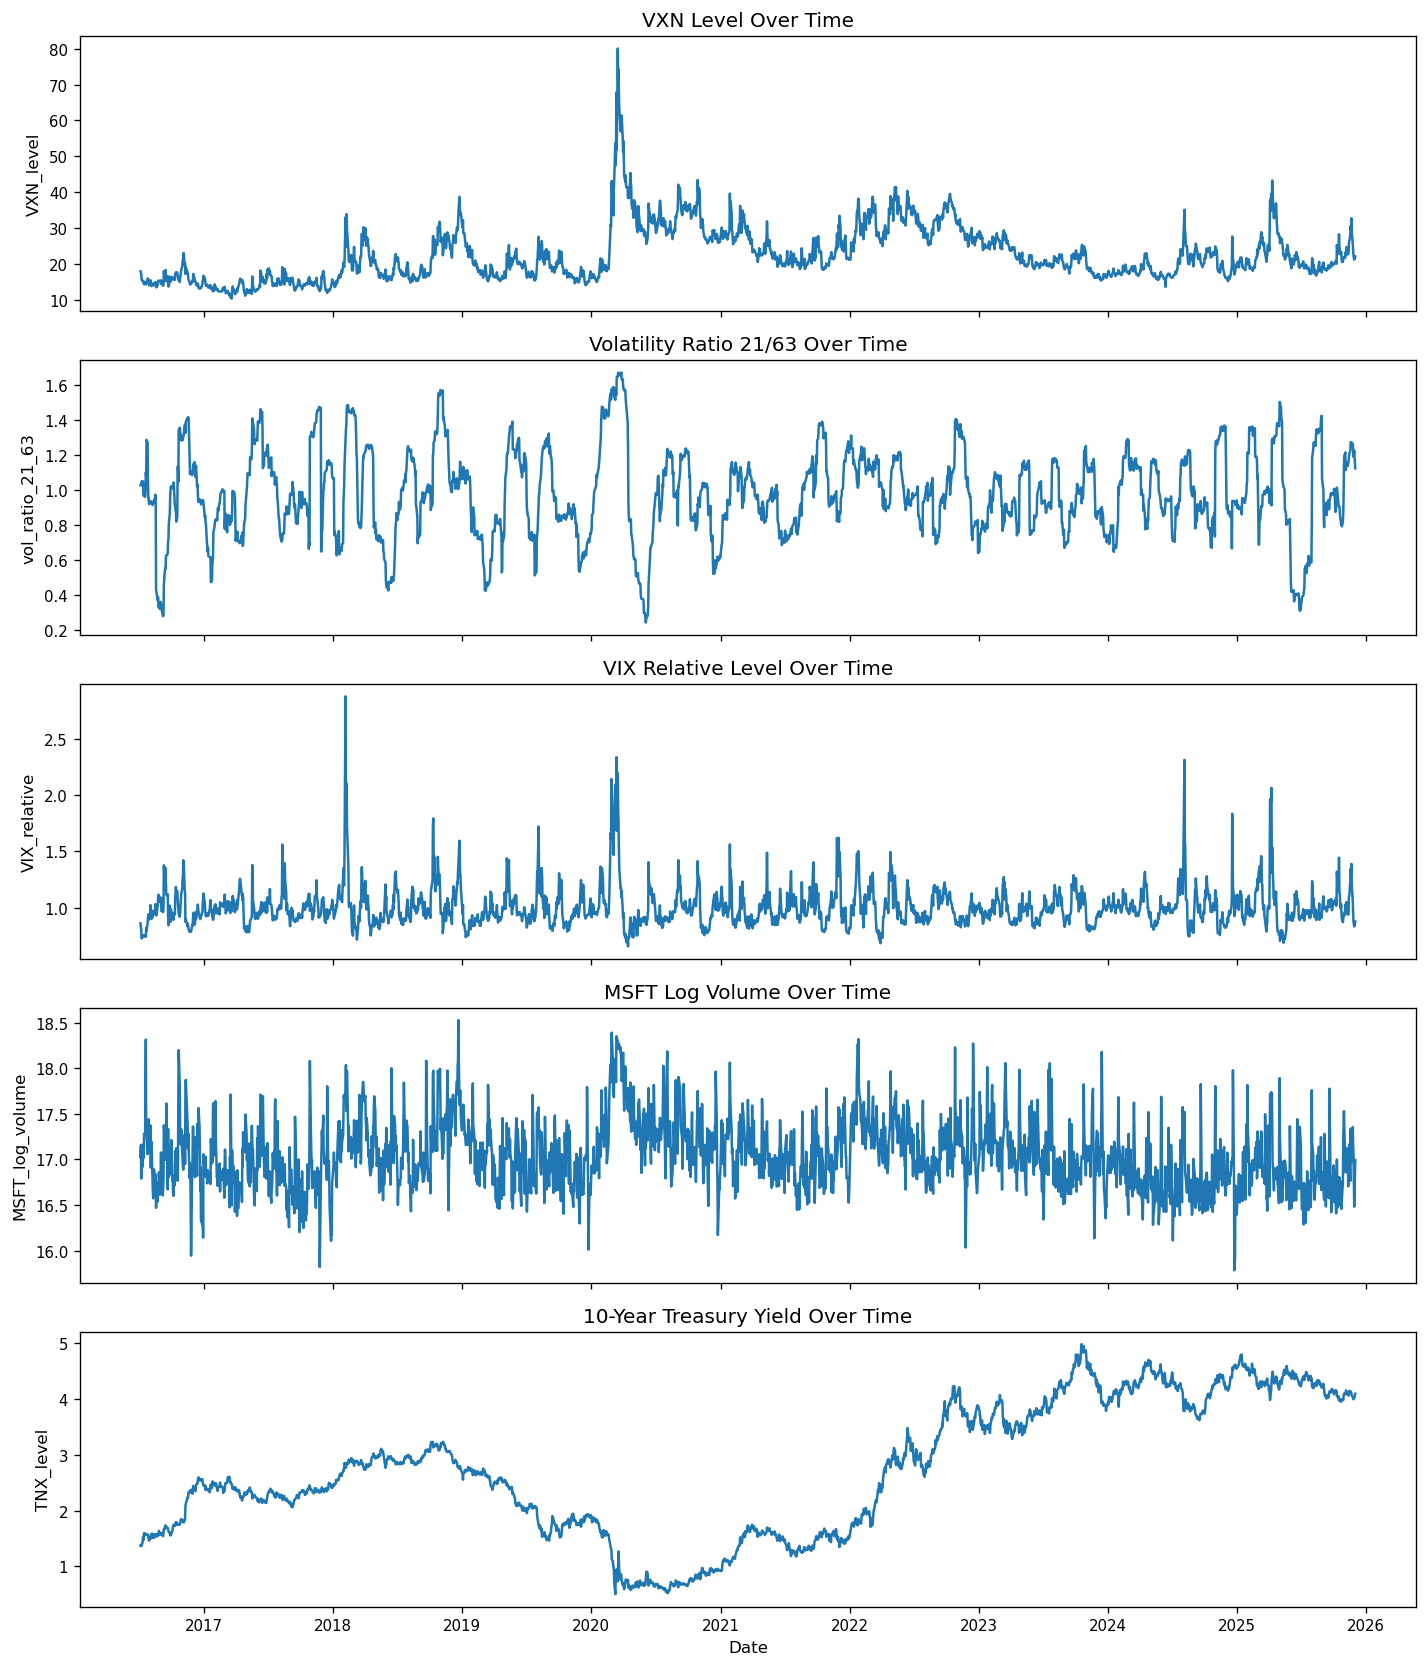

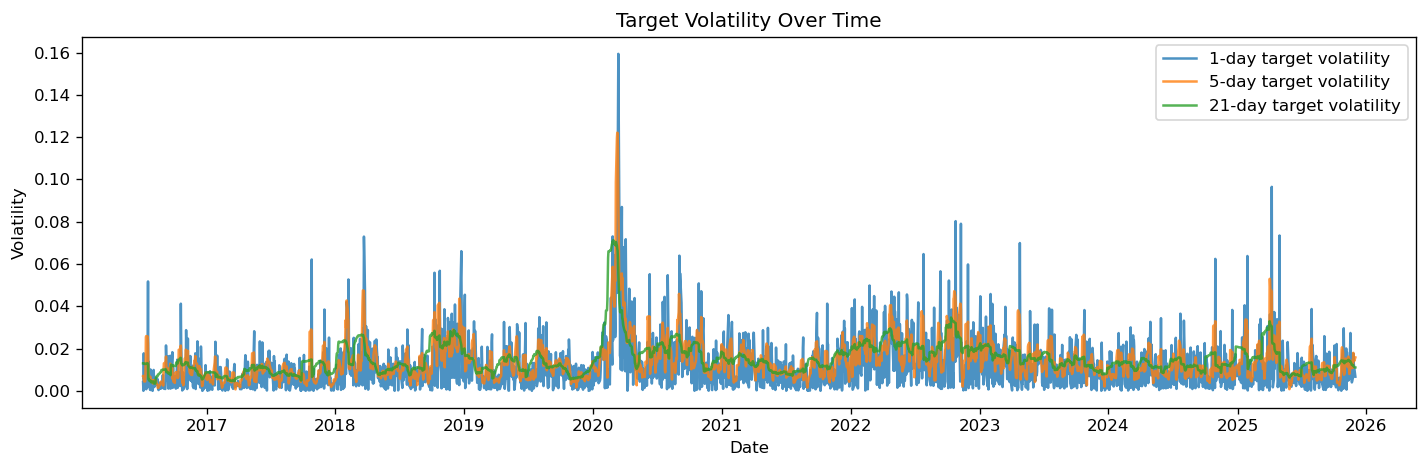

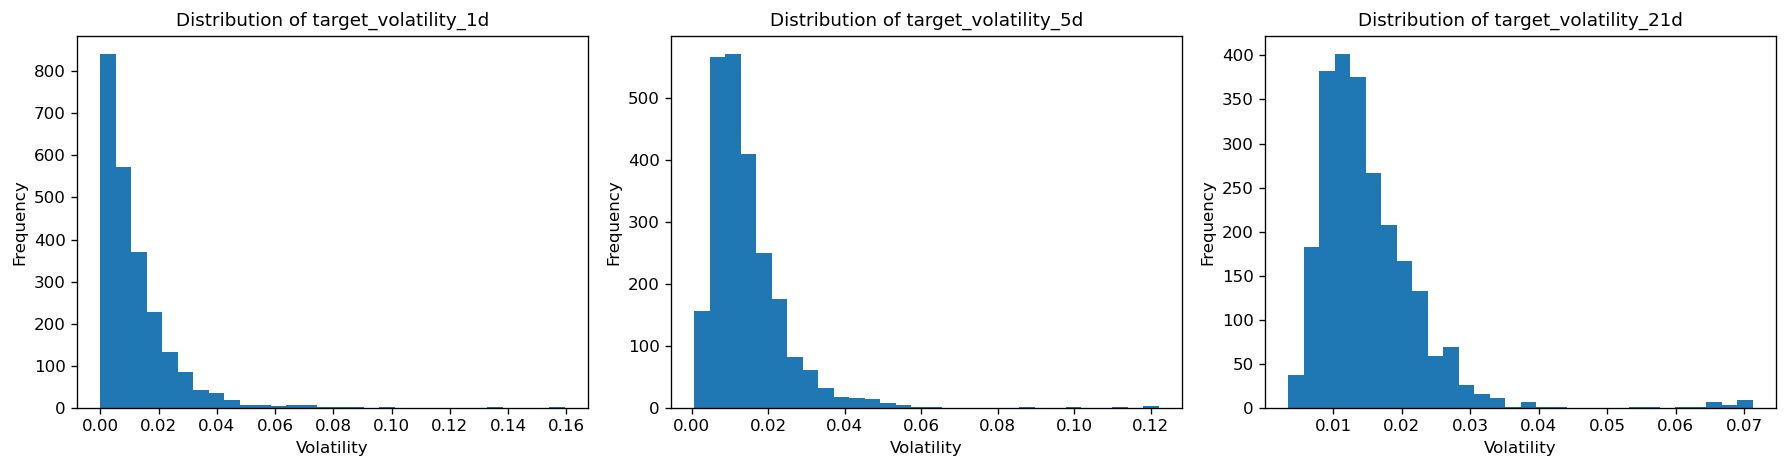

In [91]:
# Example visualization
import matplotlib.pyplot as plt

# Final selected features over time
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True, dpi=120)

feature_titles = {
    "VXN_level": "VXN Level Over Time",
    "vol_ratio_21_63": "Volatility Ratio 21/63 Over Time",
    "VIX_relative": "VIX Relative Level Over Time",
    "MSFT_log_volume": "MSFT Log Volume Over Time",
    "TNX_level": "10-Year Treasury Yield Over Time"
}

for ax, feature in zip(axes, top5_features):
    ax.plot(model_data.index, model_data[feature])
    ax.set_title(feature_titles.get(feature, feature), fontsize=12)
    ax.set_ylabel(feature, fontsize=10)
    ax.tick_params(axis="both", labelsize=9)

axes[-1].set_xlabel("Date", fontsize=10)

plt.tight_layout()
plt.show()


# Target volatility over time
plt.figure(figsize=(12, 4), dpi=120)

plt.plot(
    model_data.index,
    model_data["target_volatility_1d"],
    label="1-day target volatility",
    alpha=0.8
)

plt.plot(
    model_data.index,
    model_data["target_volatility_5d"],
    label="5-day target volatility",
    alpha=0.8
)

plt.plot(
    model_data.index,
    model_data["target_volatility_21d"],
    label="21-day target volatility",
    alpha=0.8
)

plt.title("Target Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()


# Distribution of target variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=120)

for ax, col in zip(axes, target_cols):
    ax.hist(model_data[col], bins=30)
    ax.set_title(f"Distribution of {col}", fontsize=11)
    ax.set_xlabel("Volatility")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

From the EDA plots, we can see that MSFT volatility is not stable over time. There are some periods where volatility stays high for a while, especially around 2020, which shows the idea of volatility clustering. The target volatility distributions are also right-skewed, meaning most days have low volatility, but a few days have very large spikes. This makes the prediction problem harder because those extreme spikes do not happen often. We also see that VXN and VIX-related features increase during uncertain market periods, so MSFT volatility seems to be affected by the overall market environment. TNX also changes a lot after 2021, which suggests that interest-rate conditions may also be related to stock volatility.

# 4. Methodology

The objective of this project is to predict future Microsoft (MSFT) stock volatility using historical market information and engineered financial features. We formulate the problem as a supervised learning task, where the input variables consist of stock returns, rolling volatility measures, trading volume indicators, market indices, volatility indices, interest rate variables, and earnings-related information. The target variable is future realized volatility over different forecasting horizons (1-day, 5-day, and 21-day).

To evaluate model performance, we compare several machine learning approaches including Linear Regression, Random Forest, Gradient Boosting, Support Vector Regression (SVR), and Neural Networks. All models are trained and evaluated using the same dataset and validation procedure to ensure a fair comparison.

### Hyperparameter Tuning and Validation Procedure

To make the model comparison as fair as possible, we used the same train, validation, and test split for all models. Since our data are time-series data, we used a chronological split instead of a random split. This helps avoid using future information to predict earlier volatility.

After fixing the data split, we tuned the hyperparameters separately for each model. For each model, we tried multiple values and different combinations of hyperparameters. For example, SVR was tuned using different values of `C` and `epsilon`, while tree-based models were tuned using parameters such as the number of estimators, maximum depth, and learning rate. For Lasso regression, we tuned the regularization strength `alpha`.

We used the validation set to compare different hyperparameter settings and selected the best combination for each model based on validation RMSE. After the best model settings were chosen, we evaluated the final models on the test set using the same metrics, including MAE, RMSE, normalized RMSE, and $R^2$.

## 4.1 Overview of Models
- You must try at least as many algorithms as group members.
- Each group member should implement at least one algorithm.
- Use models within the scope of the course.
- If using a more advanced model, provide sufficient background and compare it against standard baselines first.

In [22]:
# Ensure Reproducability
np.random.seed(42)

## 4.2 Model 1: Support Vector Regression (SVR)

**Implemented by: Jenny Fu**

- Motivation

Support Vector Regression (SVR) is used because future MSFT volatility may not have a simple linear relationship with the input features. Market variables such as VIX, VXN, lagged returns, rolling volatility, sector ETFs, and interest rates may affect volatility in nonlinear ways. Compared with ordinary linear regression, SVR with a kernel function can model more flexible relationships.

SVR is also suitable for noisy financial data because it uses an epsilon-insensitive margin. Small prediction errors within the margin are not penalized, while larger errors receive penalties.

- Model description

Support Vector Regression is the regression version of Support Vector Machine. Instead of classifying observations, SVR predicts a continuous target variable:

$$
f(x) = w^T x + b
$$

A key idea is the epsilon-insensitive tube. Errors within $\epsilon$ receive no penalty, while errors outside the tube are penalized. In this project, we use SVR with an RBF kernel to capture nonlinear relationships. The main hyperparameters are $C$, $\epsilon$, and $\gamma$, which control the penalty strength, margin width, and kernel flexibility.

- Why this method is appropriate/Key assumptions

SVR is appropriate because volatility prediction may depend on nonlinear combinations of historical returns, market volatility, sector movements, and interest rates. Since SVR is sensitive to feature scale, all input features are standardized. To avoid data leakage, the scaler is fitted only on the training set and then applied to the validation and test sets. The data are also split chronologically so that the model is trained on earlier observations and evaluated on later observations.

In [26]:
# SVR Training + Validation Hyperparameter Tuning
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

param_grid = [
    {'C': 0.1, 'epsilon': 0.0005, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.0005, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.0005, 'gamma': 'scale'},

    {'C': 0.1, 'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.001, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.001, 'gamma': 'scale'},

    {'C': 0.1, 'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.005, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.005, 'gamma': 'scale'},

    {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 1,   'epsilon': 0.01, 'gamma': 'scale'},
    {'C': 10,  'epsilon': 0.01, 'gamma': 'scale'},
]


def tune_svr_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    param_grid
):
    validation_results = []

    for params in param_grid:
        svr = SVR(
            kernel='rbf',
            C=params['C'],
            epsilon=params['epsilon'],
            gamma=params['gamma']
        )

        # Train on training set
        svr.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = svr.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "C": params["C"],
            "epsilon": params["epsilon"],
            "gamma": params["gamma"],
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": svr
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best hyperparameter combination for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [27]:
# Run SVR validation tuning for three targets
targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_validation_tables = []
best_svr_models = {}

for target_name, (y_train, y_valid) in targets.items():

    validation_df, best_model = tune_svr_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        param_grid=param_grid
    )

    all_validation_tables.append(validation_df)
    best_svr_models[target_name] = best_model

In [28]:
# Best SVR Validation Table
svr_validation_table = pd.concat(all_validation_tables, ignore_index=True)

best_svr_validation_table = (
    svr_validation_table[svr_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_svr_validation_table[numeric_cols] = (
    best_svr_validation_table[numeric_cols].round(4)
)

best_svr_validation_table

,Target,C,epsilon,gamma,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,0.1,0.005,scale,0.0077,0.0098,1.0738,-0.1531,Best
1,5-day volatility,0.1,0.010,scale,0.0151,0.0169,2.9284,-7.5754,Best
2,21-day volatility,10.0,0.010,scale,0.0063,0.0077,2.6336,-5.9357,Best


## 4.3 Model 2: Gradient Boost

**Implemented by: Emma Xu**

- Motivation

Gradient Boosting is used because stock volatility is likely driven by nonlinear relationships among market variables. For example, the effect of VIX on MSFT volatility may become stronger during high-volatility periods, and recent MSFT volatility may interact with market-wide volatility measures such as SPY and XLK rolling volatility. A simple linear model may not fully capture these nonlinear patterns.

- Model description

Gradient Boosting is an ensemble learning method that builds many decision trees sequentially. Each new tree is trained to correct the prediction errors made by the previous trees. Instead of fitting one large tree, the model combines many small trees to gradually improve prediction accuracy.

- Why this method is appropriate

This method is appropriate for volatility prediction because financial volatility often has nonlinear behavior, volatility clustering, and interactions between stock-specific and market-wide variables. Gradient Boosting can capture these complex patterns without requiring us to manually specify nonlinear terms.


In [63]:
# Gradient Boosting Training + Validation Hyperparameter Tuning
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

gb_param_grid = [
    {'n_estimators': 50,  'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 50,  'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 50,  'learning_rate': 0.05, 'max_depth': 2},

    {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 2},

    {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 2},

    {'n_estimators': 300, 'learning_rate': 0.01, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 2},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 2},
]


def tune_gb_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    param_grid
):
    """
    Train Gradient Boosting models with different hyperparameter combinations.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    for params in param_grid:

        gb = GradientBoostingRegressor(
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            random_state=42
        )

        # Train on training set
        gb.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = gb.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "n_estimators": params["n_estimators"],
            "learning_rate": params["learning_rate"],
            "max_depth": params["max_depth"],
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": gb
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best hyperparameter combination for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [64]:
# Run Gradient Boosting validation tuning for three targets
gb_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_gb_validation_tables = []
best_gb_models = {}

for target_name, (y_train, y_valid) in gb_targets.items():

    validation_df, best_model = tune_gb_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        param_grid=gb_param_grid
    )

    all_gb_validation_tables.append(validation_df)
    best_gb_models[target_name] = best_model

In [31]:
# Best Gradient Boosting Validation Table
gb_validation_table = pd.concat(all_gb_validation_tables, ignore_index=True)

best_gb_validation_table = (
    gb_validation_table[gb_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_gb_validation_table[numeric_cols] = (
    best_gb_validation_table[numeric_cols].round(4)
)

best_gb_validation_table

,Target,n_estimators,learning_rate,max_depth,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,100,0.01,2,0.0069,0.0089,0.9753,0.0487,Best
1,5-day volatility,50,0.01,2,0.0045,0.0056,0.9766,0.0462,Best
2,21-day volatility,100,0.01,2,0.0023,0.0028,0.9500,0.0975,Best


## 4.4 Model 3: Recurrent Neural Network (SimpleRNN)

**Implemented by: Shawn Wen**

- Motivation

The models discussed so far — SVR, Gradient Boosting, and Lasso — treat each observation independently. They receive a fixed feature vector at time $t$ and predict volatility at $t+h$, with no explicit memory of the sequence leading up to $t$. Volatility, however, is inherently a time-series phenomenon: large moves tend to cluster together (volatility clustering), and market regimes (high-vol vs. low-vol) can persist for weeks. A Recurrent Neural Network explicitly models this temporal structure by maintaining a hidden state that accumulates information across time steps, making it a natural fit for this task.
  
- Model description

At each time step $t$, a SimpleRNN layer updates its hidden state as:

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b)$$

where $x_t$ is the input at time $t$, $h_{t-1}$ is the previous hidden state, and $W_x$, $W_h$, $b$ are learned parameters. We stack two recurrent layers (with the first returning the full sequence to the second), followed by a single Dense output neuron. The model is trained with the Nadam optimizer and MSE loss.

We use a **sliding window** approach: at each time step, the model receives a sequence of the past `window_size` days of features and predicts the forward volatility.

- Why this method is appropriate

RNN is appropriate because it directly learns temporal dependencies from the raw sequence rather than relying on manually engineered lag features. Volatility clustering — the tendency for high-volatility periods to persist — is exactly the kind of sequential pattern RNNs are designed to capture. We use early stopping based on validation loss to prevent overfitting on the ~2,500 daily observations available.

In [32]:
# RNN Training + Validation Hyperparameter Tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


# Sequence helper
def make_sequences(X, y, window_size):
    Xs = []
    ys = []

    for i in range(len(X) - window_size + 1):
        Xs.append(X[i:i + window_size])
        ys.append(y[i + window_size - 1])

    return (
        np.array(Xs, dtype=np.float32),
        np.array(ys, dtype=np.float32)
    )


# RNN model
class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            nonlinearity="tanh"
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)


# Train helper
def train_rnn(
    model,
    X_train_seq,
    y_train_seq,
    X_valid_seq,
    y_valid_seq,
    epochs=100,
    batch_size=32,
    patience=15
):
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    train_ds = TensorDataset(
        torch.tensor(X_train_seq),
        torch.tensor(y_train_seq)
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False
    )

    X_valid_t = torch.tensor(X_valid_seq).to(device)
    y_valid_t = torch.tensor(y_valid_seq).to(device)

    model.to(device)

    best_val_loss = float("inf")
    best_state = None
    patience_count = 0

    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()

        total_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            pred = model(xb)
            loss = criterion(pred, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(xb)

        train_loss = total_loss / len(train_ds)
        train_losses.append(train_loss)

        model.eval()

        with torch.no_grad():
            valid_loss = criterion(
                model(X_valid_t),
                y_valid_t
            ).item()

        valid_losses.append(valid_loss)

        if valid_loss < best_val_loss:
            best_val_loss = valid_loss
            best_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }
            patience_count = 0
        else:
            patience_count += 1

            if patience_count >= patience:
                break

    model.load_state_dict(best_state)

    return model, train_losses, valid_losses


# RNN validation tuning function
def tune_rnn_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    input_size,
    param_grid
):
    """
    Train RNN models with different window sizes and hidden units.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    y_train_arr = y_train.values.astype(np.float32)
    y_valid_arr = y_valid.values.astype(np.float32)

    # Combine train and validation so validation sequences can use previous time steps
    X_train_valid = np.concatenate([X_train_scaled, X_valid_scaled])
    y_train_valid = np.concatenate([y_train_arr, y_valid_arr])

    for params in param_grid:

        window_size = params["window_size"]
        units = params["units"]

        X_seq, y_seq = make_sequences(
            X_train_valid,
            y_train_valid,
            window_size
        )

        n_train_seq = len(y_train_arr) - window_size + 1

        X_train_seq = X_seq[:n_train_seq]
        y_train_seq = y_seq[:n_train_seq]

        X_valid_seq = X_seq[n_train_seq:]
        y_valid_seq = y_seq[n_train_seq:]

        torch.manual_seed(42)

        model = SimpleRNNRegressor(
            input_size=input_size,
            hidden_size=units
        )

        model, train_losses, valid_losses = train_rnn(
            model,
            X_train_seq,
            y_train_seq,
            X_valid_seq,
            y_valid_seq
        )

        model.eval()

        with torch.no_grad():
            y_valid_pred = model(
                torch.tensor(X_valid_seq).to(device)
            ).cpu().numpy()

        valid_mae = mean_absolute_error(y_valid_seq, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid_seq, y_valid_pred))
        valid_r2 = r2_score(y_valid_seq, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid_seq)

        validation_results.append({
            "Target": target_name,
            "window_size": window_size,
            "units": units,
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": model,
            "Train Losses": train_losses,
            "Validation Losses": valid_losses
        })

    validation_df = pd.DataFrame(validation_results)

    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model


# RNN hyperparameter grid
rnn_param_grid = [
    {"window_size": 10, "units": 8},
    {"window_size": 10, "units": 16},
    {"window_size": 21, "units": 8},
    {"window_size": 21, "units": 16}
]

input_size = X_train_scaled.shape[1]

In [33]:
# Run RNN validation tuning for three targets
rnn_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_rnn_validation_tables = []
best_rnn_models = {}

for target_name, (y_train, y_valid) in rnn_targets.items():

    validation_df, best_model = tune_rnn_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        input_size=input_size,
        param_grid=rnn_param_grid
    )

    all_rnn_validation_tables.append(validation_df)
    best_rnn_models[target_name] = best_model

In [34]:
# Best RNN Validation Table
rnn_validation_table = pd.concat(all_rnn_validation_tables, ignore_index=True)

best_rnn_validation_table = (
    rnn_validation_table[rnn_validation_table["Best"] == "Best"]
    .drop(columns=["Model", "Train Losses", "Validation Losses"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_rnn_validation_table[numeric_cols] = (
    best_rnn_validation_table[numeric_cols].round(4)
)

best_rnn_validation_table

,Target,window_size,units,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,10,8,0.0071,0.0092,1.0082,-0.0164,Best
1,5-day volatility,10,8,0.0059,0.0071,1.2281,-0.5082,Best
2,21-day volatility,21,8,0.0087,0.0094,3.2177,-9.3534,Best


## 4.5 Model 4: Random Forest

**Implemented by: Zihan Zhu**

- Motivation

Random Forest is chosen because future stock volatility may depend on complex interactions among market variables. Features such as VIX, SPY returns, QQQ returns, trading volume, lagged MSFT returns, and rolling volatility may influence future volatility in a nonlinear way. A simple linear model may not fully capture these relationships.

Random Forest is also robust to noisy financial data. By averaging predictions from many decision trees, it can reduce overfitting and improve prediction stability compared with a single decision tree.

- Model description

Random Forest is an ensemble learning method based on bagging. The model builds many decision trees using bootstrap samples of the training data. At each split, only a random subset of features is considered, which increases diversity among trees.

For a regression problem, the final prediction is the average prediction across all trees in the forest. In this project, we tune the main hyperparameters including the number of trees (n_estimators), maximum tree depth (max_depth), and minimum number of samples required in a leaf node (min_samples_leaf). The best parameter combination is selected using validation RMSE.


- Why this method is appropriate

Random Forest is appropriate because stock volatility often exhibits nonlinear behavior and interactions among market indicators. It can capture these patterns without requiring us to manually specify nonlinear terms or interaction effects.

The main assumption is that historical market information contains useful signals for future volatility prediction. We also split the data chronologically into training, validation, and test sets to avoid look-ahead bias. Since Random Forest is tree-based, feature scaling is not required, making it relatively robust to differences in feature magnitude.

In [35]:
# Random Forest Training + Validation Hyperparameter Tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

rf_param_grid = []

# Round 1: Initial Search
for n_estimators in [100, 200]:
    for max_depth in [3, 5, 8]:
        for min_samples_leaf in [3, 5, 10]:
            rf_param_grid.append({
                "Search Round": "Initial Search",
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf
            })

# Round 2: Refined Search
for max_depth in [2, 3, 4, 5, 6]:
    for min_samples_leaf in [8, 10, 12]:
        rf_param_grid.append({
            "Search Round": "Refined Search",
            "n_estimators": 200,
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf
        })


def tune_rf_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    param_grid
):
    """
    Train Random Forest models with different hyperparameter combinations.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    for params in param_grid:

        rf = RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        )

        # Train on training set
        rf.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = rf.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "Search Round": params["Search Round"],
            "n_estimators": params["n_estimators"],
            "max_depth": params["max_depth"],
            "min_samples_leaf": params["min_samples_leaf"],
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": rf
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best hyperparameter combination for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [36]:
# Run Random Forest validation tuning for three targets
rf_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_rf_validation_tables = []
best_rf_models = {}

for target_name, (y_train, y_valid) in rf_targets.items():

    validation_df, best_model = tune_rf_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        param_grid=rf_param_grid
    )

    all_rf_validation_tables.append(validation_df)
    best_rf_models[target_name] = best_model

In [37]:
# Best Random Forest Validation Table
rf_validation_table = pd.concat(all_rf_validation_tables, ignore_index=True)

best_rf_validation_table = (
    rf_validation_table[rf_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_rf_validation_table[numeric_cols] = (
    best_rf_validation_table[numeric_cols].round(4)
)

best_rf_validation_table

,Target,Search Round,n_estimators,max_depth,min_samples_leaf,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,Initial Search,200,3,3,0.0068,0.0088,0.9681,0.0627,Best
1,5-day volatility,Refined Search,200,2,8,0.0045,0.0060,1.0353,-0.0718,Best
2,21-day volatility,Refined Search,200,2,10,0.0025,0.0031,1.0743,-0.1541,Best


## 4.6 Additional Model 1: Lasso regression

**Implemented by: Jenny Fu**

- Motivation

Lasso Regression is used as a regularized linear regression model for predicting future MSFT volatility. Since we have many financial features, including lagged returns, rolling volatility, market index returns, volatility indexes, sector ETFs, and interest rate variables, some features may be more useful than others. Lasso is helpful because it can shrink less important feature coefficients toward zero and reduce the risk of overfitting.

Lasso also provides a simpler and more interpretable model compared with nonlinear models such as SVR. This makes it useful as a baseline model for understanding whether a regularized linear relationship can explain future volatility.


- Model description

Lasso Regression, short for Least Absolute Shrinkage and Selection Operator, is a regularized linear regression method. It adds an \(L_1\) penalty to the usual least squares loss. The objective function can be written as:

$$
\min_{\beta} \|y - X\beta\|^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

Equivalently, it can also be written in constrained form as:

$$
\min_{\beta} \|y - X\beta\|^2
\quad \text{subject to} \quad
\sum_{j=1}^{p} |\beta_j| \leq s
$$

The $L_1$ penalty shrinks the regression coefficients, and it can set some coefficients exactly equal to zero. Therefore, Lasso can perform feature selection by keeping the more important predictors and removing less important ones. In this project, the tuning parameter is $\alpha$, which controls the strength of the $L_1$ penalty. A larger $\alpha$ means stronger regularization.

- Why this method is appropriate

Lasso is appropriate for this project because the dataset includes many related financial features, and some of them may be redundant or weakly useful. By applying \(L_1\) regularization, Lasso can reduce model complexity and help select the most relevant predictors.

Since Lasso is sensitive to feature scale, all input features are standardized before training. To avoid data leakage, the scaler is fitted only on the training set and then applied to the validation and test sets. The data are also split chronologically, so the model is trained on earlier observations and evaluated on later observations.

In [68]:
# Lasso Training + Validation Hyperparameter Tuning
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

alpha_grid = [
    0.000001,
    0.000005,
    0.00001,
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

def tune_lasso_validation(
    target_name,
    y_train,
    y_valid,
    X_train_scaled,
    X_valid_scaled,
    alpha_grid
):
    """
    Train Lasso models with different alpha values.
    Evaluate each model on the validation set.
    Select the best model based on validation RMSE.
    """

    validation_results = []

    for alpha in alpha_grid:
        lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)

        # Train on training set
        lasso.fit(X_train_scaled, y_train)

        # Predict on validation set
        y_valid_pred = lasso.predict(X_valid_scaled)

        # Validation metrics
        valid_mae = mean_absolute_error(y_valid, y_valid_pred)
        valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
        valid_r2 = r2_score(y_valid, y_valid_pred)
        valid_normalized_rmse = valid_rmse / np.std(y_valid)

        validation_results.append({
            "Target": target_name,
            "alpha": alpha,
            "Validation MAE": valid_mae,
            "Validation RMSE": valid_rmse,
            "Validation Normalized RMSE": valid_normalized_rmse,
            "Validation R2": valid_r2,
            "Model": lasso
        })

    validation_df = pd.DataFrame(validation_results)

    # Mark the best alpha for this target
    best_idx = validation_df["Validation RMSE"].idxmin()
    validation_df["Best"] = ""
    validation_df.loc[best_idx, "Best"] = "Best"

    best_model = validation_df.loc[best_idx, "Model"]

    return validation_df, best_model

In [69]:
# Run Lasso validation tuning for three targets
lasso_targets = {
    "1-day volatility": (y_train_1d, y_valid_1d),
    "5-day volatility": (y_train_5d, y_valid_5d),
    "21-day volatility": (y_train_21d, y_valid_21d)
}

all_lasso_validation_tables = []
best_lasso_models = {}

for target_name, (y_train, y_valid) in lasso_targets.items():

    validation_df, best_model = tune_lasso_validation(
        target_name=target_name,
        y_train=y_train,
        y_valid=y_valid,
        X_train_scaled=X_train_scaled,
        X_valid_scaled=X_valid_scaled,
        alpha_grid=alpha_grid
    )

    all_lasso_validation_tables.append(validation_df)
    best_lasso_models[target_name] = best_model

In [70]:
# Best Lasso Validation Table
lasso_validation_table = pd.concat(all_lasso_validation_tables, ignore_index=True)

best_lasso_validation_table = (
    lasso_validation_table[lasso_validation_table["Best"] == "Best"]
    .drop(columns=["Model"])
    .copy()
    .reset_index(drop=True)
)

numeric_cols = [
    "Validation MAE",
    "Validation RMSE",
    "Validation Normalized RMSE",
    "Validation R2"
]

best_lasso_validation_table[numeric_cols] = (
    best_lasso_validation_table[numeric_cols].round(4)
)

best_lasso_validation_table

,Target,alpha,Validation MAE,Validation RMSE,Validation Normalized RMSE,Validation R2,Best
0,1-day volatility,0.001,0.0067,0.0089,0.9732,0.0528,Best
1,5-day volatility,0.001,0.0042,0.0056,0.9706,0.0579,Best
2,21-day volatility,0.001,0.0022,0.0027,0.9405,0.1154,Best


# 5. Results

We mainly compare the models using Test MAE, Test RMSE, Test Normalized RMSE, Test $R^2$, Baseline RMSE, and Improvement over Baseline.

## 5.1 Evaluation Metrics

We use MAE, RMSE, normalized RMSE, and $R^2$ to evaluate model performance. MAE measures the average prediction error, while RMSE gives more weight to larger errors. This is useful in volatility prediction because volatility can have sudden spikes. Normalized RMSE helps us compare results across different prediction horizons, such as 1-day, 5-day, and 21-day volatility. We also report $R^2$ and improvement over baseline to see whether each model performs better than a simple baseline prediction.

In [71]:
# Test Evaluation Summary Table (Function)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_test_models(
    models,
    test_targets,
    train_targets,
    X_test_scaled,
    include_params=True
):
    """
    Evaluate trained models on the test set.

    models: dictionary of fitted models
    test_targets: dictionary of test target values
    train_targets: dictionary of training target values, used for naive baseline
    X_test_scaled: standardized test features
    include_params: whether to include model hyperparameters if available
    """

    test_results = []

    for target_name, y_test in test_targets.items():

        model = models[target_name]
        y_test_pred = model.predict(X_test_scaled)

        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        test_r2 = r2_score(y_test, y_test_pred)
        test_normalized_rmse = test_rmse / np.std(y_test)

        y_train = train_targets[target_name]
        baseline_pred = np.repeat(y_train.mean(), len(y_test))
        baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

        improvement_over_baseline = (
            baseline_rmse - test_rmse
        ) / baseline_rmse

        result = {
            "Target": target_name,
            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test Normalized RMSE": test_normalized_rmse,
            "Test R2": test_r2,
            "Baseline RMSE": baseline_rmse,
            "Improvement over Baseline": improvement_over_baseline
        }

        if include_params and hasattr(model, "get_params"):
            params = model.get_params()

            if "C" in params:
                result["C"] = params["C"]
            if "epsilon" in params:
                result["epsilon"] = params["epsilon"]
            if "gamma" in params:
                result["gamma"] = params["gamma"]

        test_results.append(result)

    test_summary = pd.DataFrame(test_results)


    preferred_cols = [
        "Target",
        "C",
        "epsilon",
        "gamma",
        "Test MAE",
        "Test RMSE",
        "Test Normalized RMSE",
        "Test R2",
        "Baseline RMSE",
        "Improvement over Baseline"
    ]

    existing_cols = [col for col in preferred_cols if col in test_summary.columns]
    test_summary = test_summary[existing_cols]

    numeric_cols = test_summary.select_dtypes(include=[np.number]).columns
    test_summary[numeric_cols] = test_summary[numeric_cols].round(4)

    return test_summary

In [42]:
# RNN Test Evaluation Summary Table (Function)
def evaluate_rnn_test_models(
    models,
    best_validation_table,
    test_targets,
    train_targets,
    valid_targets,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled
):
    """
    Evaluate trained RNN models on the test set.
    RNN needs sequence inputs, so this function builds test sequences
    using train + validation + test data in chronological order.
    """

    test_results = []

    X_all = np.concatenate([
        np.asarray(X_train_scaled),
        np.asarray(X_valid_scaled),
        np.asarray(X_test_scaled)
    ])

    n_train = len(X_train_scaled)
    n_valid = len(X_valid_scaled)

    for target_name, y_test in test_targets.items():

        model = models[target_name]

        # Get best RNN hyperparameters from validation table
        best_row = best_validation_table[
            best_validation_table["Target"] == target_name
        ].iloc[0]

        window_size = int(best_row["window_size"])
        units = int(best_row["units"])

        y_train = train_targets[target_name]
        y_valid = valid_targets[target_name]

        y_all = np.concatenate([
            y_train.values.astype(np.float32),
            y_valid.values.astype(np.float32),
            y_test.values.astype(np.float32)
        ])

        X_seq, y_seq = make_sequences(
            X_all,
            y_all,
            window_size
        )

        # Test sequences start at the first test observation
        test_start = n_train + n_valid - window_size + 1

        X_test_seq = X_seq[test_start:]
        y_test_seq = y_seq[test_start:]

        model.eval()

        with torch.no_grad():
            y_test_pred = model(
                torch.tensor(X_test_seq).to(device)
            ).cpu().numpy()

        # Test metrics
        test_mae = mean_absolute_error(y_test_seq, y_test_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test_seq, y_test_pred))
        test_r2 = r2_score(y_test_seq, y_test_pred)
        test_normalized_rmse = test_rmse / np.std(y_test_seq)

        # Naive baseline: predict training mean
        baseline_pred = np.repeat(y_train.mean(), len(y_test_seq))
        baseline_rmse = np.sqrt(mean_squared_error(y_test_seq, baseline_pred))
        improvement_over_baseline = (
            baseline_rmse - test_rmse
        ) / baseline_rmse

        test_results.append({
            "Target": target_name,
            "window_size": window_size,
            "units": units,
            "Test MAE": test_mae,
            "Test RMSE": test_rmse,
            "Test Normalized RMSE": test_normalized_rmse,
            "Test R2": test_r2,
            "Baseline RMSE": baseline_rmse,
            "Improvement over Baseline": improvement_over_baseline
        })

    rnn_test_summary = pd.DataFrame(test_results)

    numeric_cols = [
        "Test MAE",
        "Test RMSE",
        "Test Normalized RMSE",
        "Test R2",
        "Baseline RMSE",
        "Improvement over Baseline"
    ]

    rnn_test_summary[numeric_cols] = (
        rnn_test_summary[numeric_cols].round(4)
    )

    return rnn_test_summary

In [46]:
# Run Test Summary Tables
from IPython.display import display

test_targets = {
    "1-day volatility": y_test_1d,
    "5-day volatility": y_test_5d,
    "21-day volatility": y_test_21d
}

train_targets = {
    "1-day volatility": y_train_1d,
    "5-day volatility": y_train_5d,
    "21-day volatility": y_train_21d
}

valid_targets = {
    "1-day volatility": y_valid_1d,
    "5-day volatility": y_valid_5d,
    "21-day volatility": y_valid_21d
}

# SVR test summary
svr_test_summary = evaluate_test_models(
    models=best_svr_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)

# Gradient Boosting test summary
gb_test_summary = evaluate_test_models(
    models=best_gb_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)

# RNN test summary
rnn_test_summary = evaluate_rnn_test_models(
    models=best_rnn_models,
    best_validation_table=best_rnn_validation_table,
    test_targets=test_targets,
    train_targets=train_targets,
    valid_targets=valid_targets,
    X_train_scaled=X_train_scaled,
    X_valid_scaled=X_valid_scaled,
    X_test_scaled=X_test_scaled
)

# Random Forest test summary
rf_test_summary = evaluate_test_models(
    models=best_rf_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)

# Lasso test summary
lasso_test_summary = evaluate_test_models(
    models=best_lasso_models,
    test_targets=test_targets,
    train_targets=train_targets,
    X_test_scaled=X_test_scaled,
    include_params=True
)


print("SVR Test Summary Table")
display(svr_test_summary)

print("Gradient Boosting Test Summary Table")
display(gb_test_summary)

print("RNN Test Summary Table")
display(rnn_test_summary)

print("Random Forest Test Summary Table")
display(rf_test_summary)

print("Lasso Test Summary Table")
display(lasso_test_summary)

SVR Test Summary Table


,Target,C,epsilon,gamma,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.1,0.005,scale,0.0097,0.0126,1.1754,-0.3816,0.0109,-0.1543
1,5-day volatility,0.1,0.010,scale,0.0181,0.0194,2.5210,-5.3556,0.0080,-1.4193
2,21-day volatility,10.0,0.010,scale,0.0112,0.0138,2.6318,-5.9263,0.0056,-1.4475


Gradient Boosting Test Summary Table


,Target,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0074,0.0105,0.9791,0.0413,0.0109,0.0384
1,5-day volatility,0.0057,0.0076,0.9932,0.0136,0.0080,0.0469
2,21-day volatility,0.0041,0.0052,0.9814,0.0369,0.0056,0.0873


RNN Test Summary Table


,Target,window_size,units,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,10,8,0.0087,0.0120,1.1236,-0.2624,0.0109,-0.1034
1,5-day volatility,10,8,0.0093,0.0114,1.4883,-1.2150,0.0080,-0.4282
2,21-day volatility,21,8,0.0128,0.0141,2.6958,-6.2672,0.0056,-1.5070


Random Forest Test Summary Table


,Target,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0077,0.0106,0.9928,0.0143,0.0109,0.0250
1,5-day volatility,0.0057,0.0078,1.0171,-0.0344,0.0080,0.0240
2,21-day volatility,0.0039,0.0053,1.0131,-0.0264,0.0056,0.0578


Lasso Test Summary Table


,Target,Test MAE,Test RMSE,Test Normalized RMSE,Test R2,Baseline RMSE,Improvement over Baseline
0,1-day volatility,0.0072,0.0104,0.9703,0.0585,0.0109,0.0471
1,5-day volatility,0.0054,0.0075,0.9736,0.0521,0.0080,0.0657
2,21-day volatility,0.0041,0.0052,0.9819,0.0359,0.0056,0.0869


## 5.2 Main Quantitative Results

For SVR, the test performance is relatively weak. The 1-day volatility model has a Test RMSE of 0.0126 and a Test $R^2$ of -0.3816. The 5-day and 21-day volatility results are worse, with Test $R^2$ values of -5.3556 and -5.9263. The improvement over baseline is also negative for all three horizons, which means SVR performs worse than the baseline in this setting.

Gradient Boosting performs better than SVR. For 1-day volatility, it has a Test RMSE of 0.0105 and a Test $R^2$ of 0.0413. For 5-day volatility, the Test RMSE is 0.0076 with a Test R² of 0.0136. For 21-day volatility, the Test RMSE is 0.0052 and the Test $R^2$ is 0.0369. The improvement over baseline is positive for all three horizons, ranging from 0.0384 to 0.0873.

Random Forest also gives relatively stable results. Its Test RMSE values are 0.0106 for 1-day volatility, 0.0078 for 5-day volatility, and 0.0053 for 21-day volatility. The 1-day model has a positive Test $R^2$ of 0.0143, while the 5-day and 21-day models have slightly negative $R^2$ values of -0.0344 and -0.0264. However, the improvement over baseline is still positive for all three horizons.

Lasso gives one of the better overall results. For 1-day volatility, it has a Test RMSE of 0.0104 and a Test $R^2$ of 0.0585. For 5-day volatility, it has a Test RMSE of 0.0075 and a Test $R^2$ of 0.0521. For 21-day volatility, it has a Test RMSE of 0.0052 and a Test $R^2$ of 0.0359. The improvement over baseline is also positive for all three horizons, with values of 0.0471, 0.0657, and 0.0869.

The RNN model does not perform well compared with the tree-based models and Lasso. Its Test RMSE values are 0.0120 for 1-day volatility, 0.0114 for 5-day volatility, and 0.0141 for 21-day volatility. The Test $R^2$ values are negative for all three horizons, especially for 21-day volatility, where the $R^2$ is -6.2672. Its improvement over baseline is also negative across all horizons.

Overall, the quantitative results show that Gradient Boosting and Lasso generally perform better on the test set. 

## 5.3 Visualizations

Based on the tables above, we selected the two best-performing models based on R² and MAE: **Lasso** and **Gradient Boosting**. Therefore, in the visualization section, we only include the daily, weekly, and monthly prediction plots for Lasso and Gradient Boosting. The remaining model visualizations are included in the appendix.

In [82]:
# Visualization Functions
# Actual vs Predicted, Residual Plots, Permutation Feature Importance
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.inspection import permutation_importance


def plot_actual_vs_predicted_single_model(
    model,
    y_true,
    X_test_final,
    model_name,
    target_name,
    dataset_name="Test"
):
    """
    Plot actual and predicted volatility over time
    for one model and one target.
    """

    y_pred = model.predict(X_test_final)

    plt.figure(figsize=(12, 4), dpi=120)

    plt.plot(y_true.index, y_true, label="Actual", linewidth=2)
    plt.plot(y_true.index, y_pred, label="Predicted", alpha=0.8)

    plt.title(f"{model_name} {dataset_name} Actual vs Predicted: {target_name}")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_pred


def plot_residuals_side_by_side(
    left_models,
    right_models,
    targets,
    X_test_final,
    left_model_name,
    right_model_name,
    dataset_name="Test"
):
    """
    Plot residuals in a side-by-side layout.

    Left column: left_models
    Right column: right_models
    Rows: target variables, such as 1-day, 5-day, and 21-day volatility.
    """

    n_targets = len(targets)

    fig, axes = plt.subplots(
        nrows=n_targets,
        ncols=2,
        figsize=(14, 4 * n_targets),
        dpi=120
    )

    if n_targets == 1:
        axes = axes.reshape(1, 2)

    residuals_dict = {
        left_model_name: {},
        right_model_name: {}
    }

    for row_idx, (target_name, y_true) in enumerate(targets.items()):

        # Left model
        left_model = left_models[target_name]
        left_pred = left_model.predict(X_test_final)
        left_residuals = y_true - left_pred
        residuals_dict[left_model_name][target_name] = left_residuals

        ax = axes[row_idx, 0]
        ax.scatter(left_pred, left_residuals, alpha=0.6, s=28)
        ax.axhline(y=0, linestyle="--")
        ax.set_title(f"{left_model_name}: {target_name}", fontsize=12)
        ax.set_xlabel("Predicted Volatility", fontsize=10)
        ax.set_ylabel("Residuals", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

        # Right model
        right_model = right_models[target_name]
        right_pred = right_model.predict(X_test_final)
        right_residuals = y_true - right_pred
        residuals_dict[right_model_name][target_name] = right_residuals

        ax = axes[row_idx, 1]
        ax.scatter(right_pred, right_residuals, alpha=0.6, s=28)
        ax.axhline(y=0, linestyle="--")
        ax.set_title(f"{right_model_name}: {target_name}", fontsize=12)
        ax.set_xlabel("Predicted Volatility", fontsize=10)
        ax.set_ylabel("Residuals", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

    fig.suptitle(
        f"{dataset_name} Residual Plots: {left_model_name} vs {right_model_name}",
        fontsize=15,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

    return residuals_dict


def plot_importance_side_by_side(
    left_models,
    right_models,
    targets,
    X_test_final,
    final_feature_cols,
    left_model_name,
    right_model_name,
    top_n=5,
    dataset_name="Test"
):
    """
    Plot permutation feature importance in a side-by-side layout.

    Left column: left_models
    Right column: right_models
    Rows: target variables, such as 1-day, 5-day, and 21-day volatility.
    """

    n_targets = len(targets)

    fig, axes = plt.subplots(
        nrows=n_targets,
        ncols=2,
        figsize=(15, 4 * n_targets),
        dpi=120
    )

    if n_targets == 1:
        axes = axes.reshape(1, 2)

    importance_dict = {
        left_model_name: {},
        right_model_name: {}
    }

    for row_idx, (target_name, y_true) in enumerate(targets.items()):

        # Left model
        left_model = left_models[target_name]

        left_result = permutation_importance(
            left_model,
            X_test_final,
            y_true,
            n_repeats=10,
            random_state=42,
            scoring="neg_root_mean_squared_error"
        )

        left_importance_df = pd.DataFrame({
            "Feature": final_feature_cols,
            "Importance": left_result.importances_mean,
            "Importance Std": left_result.importances_std
        }).sort_values(by="Importance", ascending=False)

        importance_dict[left_model_name][target_name] = left_importance_df

        left_top = left_importance_df.head(top_n)

        ax = axes[row_idx, 0]
        ax.barh(
            left_top["Feature"][::-1],
            left_top["Importance"][::-1]
        )
        ax.set_title(f"{left_model_name}: {target_name}", fontsize=12)
        ax.set_xlabel(f"Increase in {dataset_name} RMSE", fontsize=10)
        ax.set_ylabel("Feature", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

        # Right model
        right_model = right_models[target_name]

        right_result = permutation_importance(
            right_model,
            X_test_final,
            y_true,
            n_repeats=10,
            random_state=42,
            scoring="neg_root_mean_squared_error"
        )

        right_importance_df = pd.DataFrame({
            "Feature": final_feature_cols,
            "Importance": right_result.importances_mean,
            "Importance Std": right_result.importances_std
        }).sort_values(by="Importance", ascending=False)

        importance_dict[right_model_name][target_name] = right_importance_df

        right_top = right_importance_df.head(top_n)

        ax = axes[row_idx, 1]
        ax.barh(
            right_top["Feature"][::-1],
            right_top["Importance"][::-1]
        )
        ax.set_title(f"{right_model_name}: {target_name}", fontsize=12)
        ax.set_xlabel(f"Increase in {dataset_name} RMSE", fontsize=10)
        ax.set_ylabel("Feature", fontsize=10)
        ax.tick_params(axis="both", labelsize=9)

    fig.suptitle(
        f"{dataset_name} Permutation Feature Importance: {left_model_name} vs {right_model_name}",
        fontsize=15,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

    return importance_dict

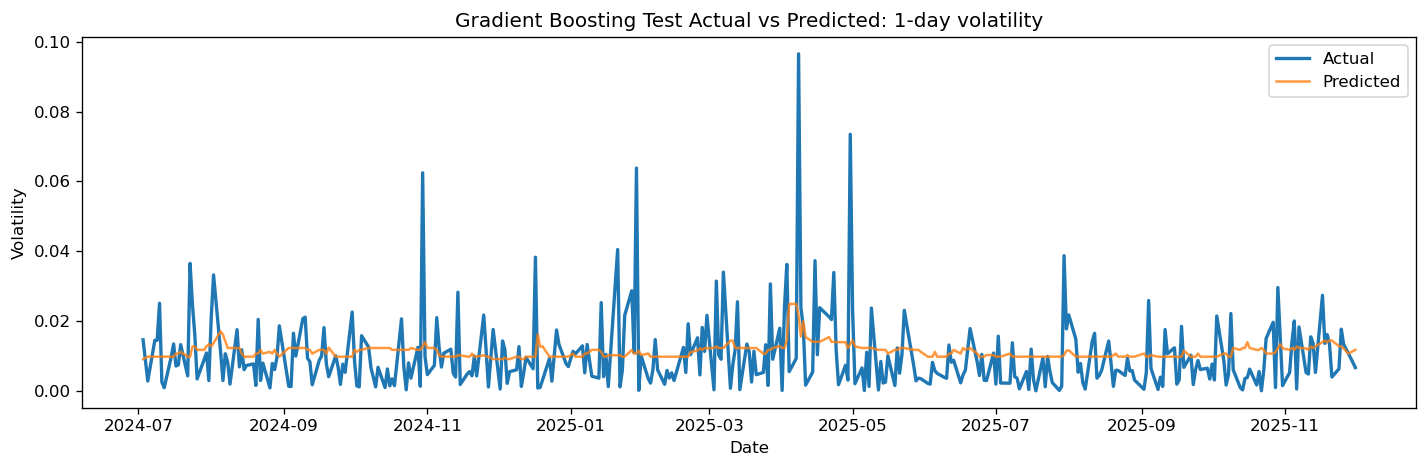

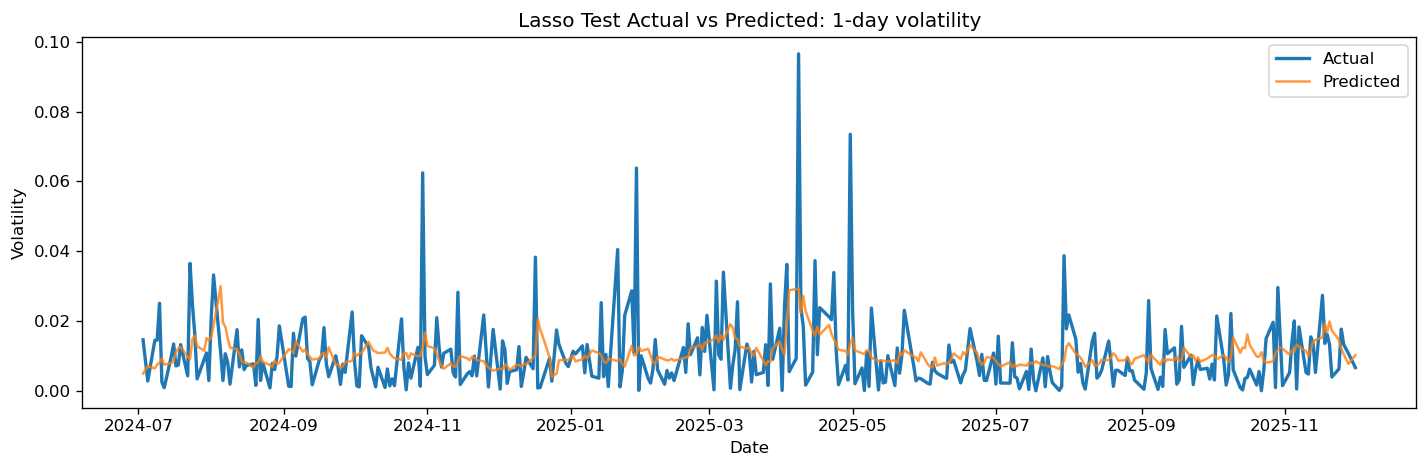

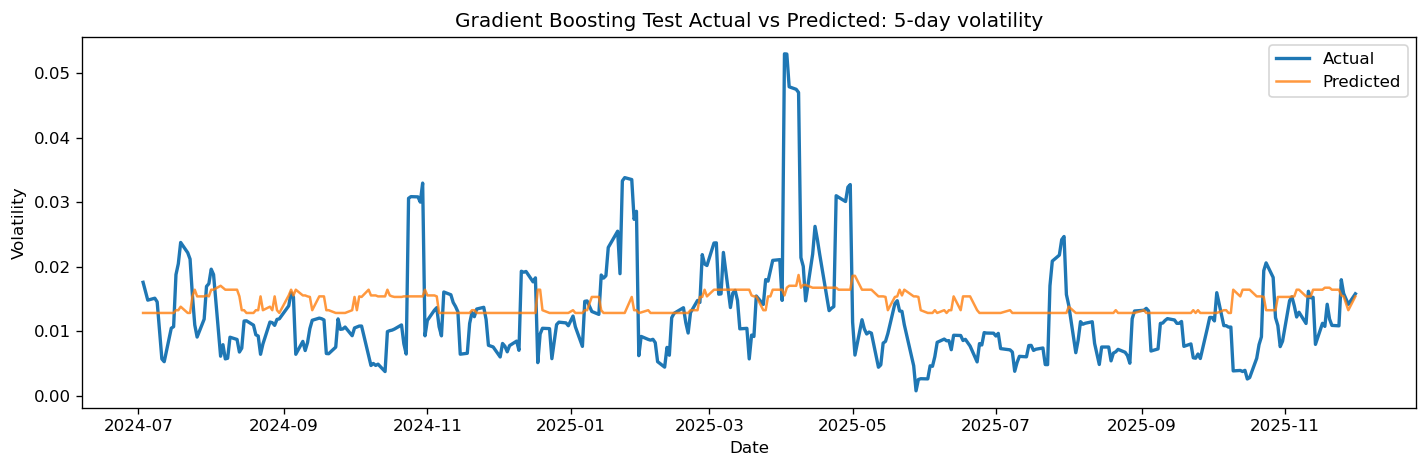

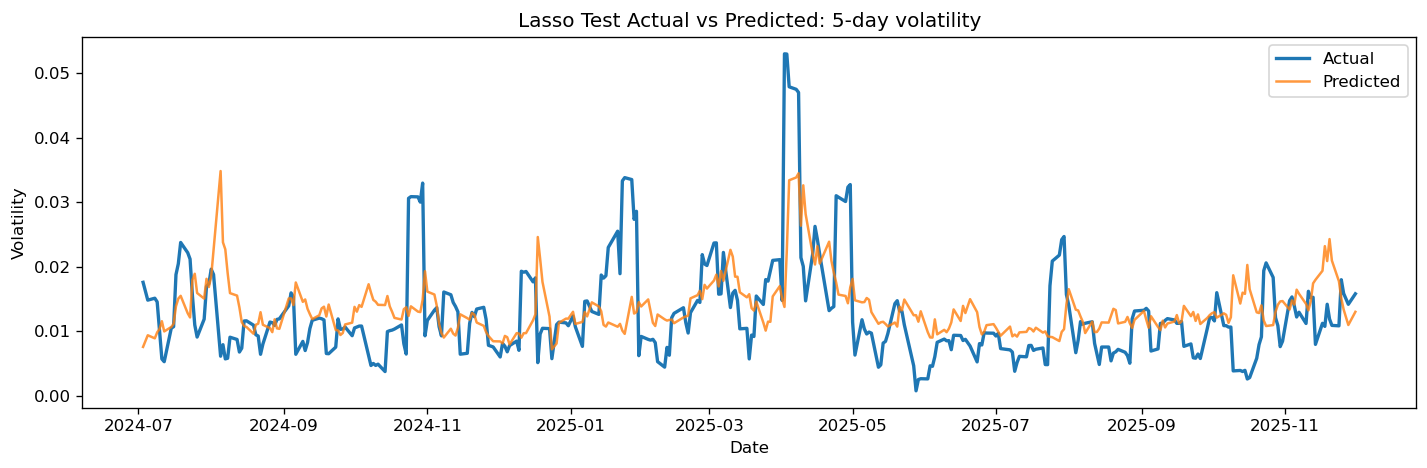

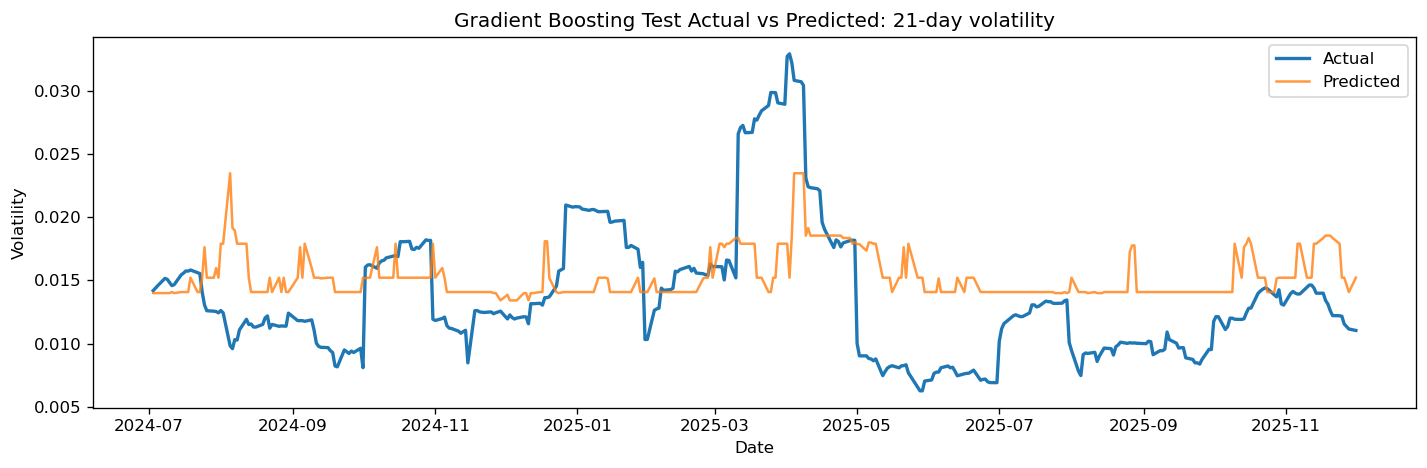

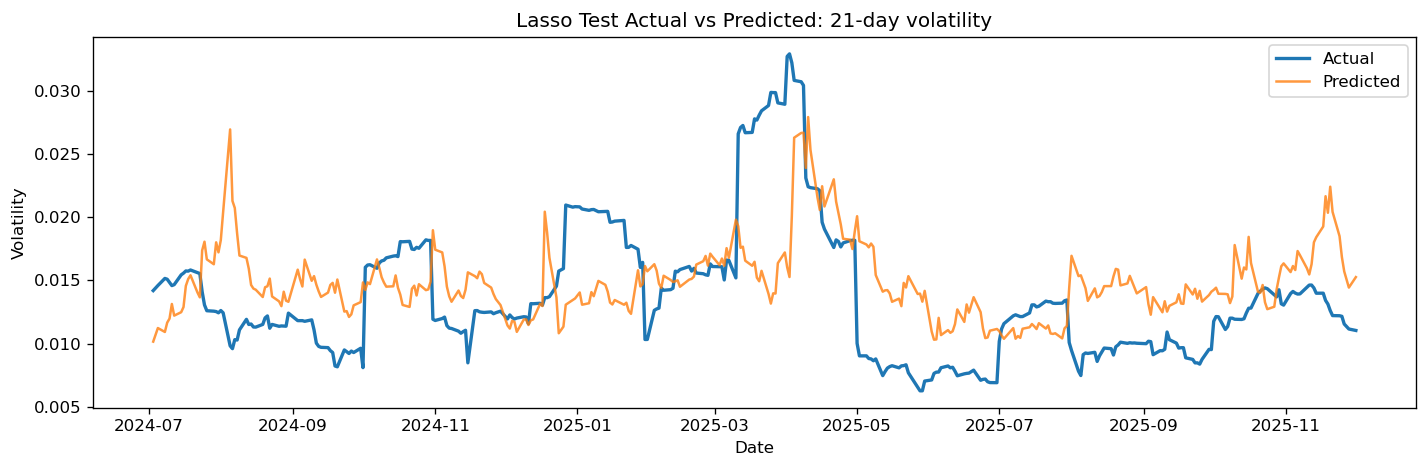

In [85]:
# Test Visualization Results
# Predicted vs Actual plots

# Daily
# Gradient Boosting
gb_pred_1d = plot_actual_vs_predicted_single_model(
    model=best_gb_models["1-day volatility"],
    y_true=y_test_1d,
    X_test_final=X_test_scaled,
    model_name="Gradient Boosting",
    target_name="1-day volatility",
    dataset_name="Test"
)

# Lasso
lasso_pred_1d = plot_actual_vs_predicted_single_model(
    model=best_lasso_models["1-day volatility"],
    y_true=y_test_1d,
    X_test_final=X_test_scaled,
    model_name="Lasso",
    target_name="1-day volatility",
    dataset_name="Test"
)


# Weekly
# Gradient Boosting
gb_pred_5d = plot_actual_vs_predicted_single_model(
    model=best_gb_models["5-day volatility"],
    y_true=y_test_5d,
    X_test_final=X_test_scaled,
    model_name="Gradient Boosting",
    target_name="5-day volatility",
    dataset_name="Test"
)

# Lasso
lasso_pred_5d = plot_actual_vs_predicted_single_model(
    model=best_lasso_models["5-day volatility"],
    y_true=y_test_5d,
    X_test_final=X_test_scaled,
    model_name="Lasso",
    target_name="5-day volatility",
    dataset_name="Test"
)


# Monthly
# Gradient Boosting
gb_pred_21d = plot_actual_vs_predicted_single_model(
    model=best_gb_models["21-day volatility"],
    y_true=y_test_21d,
    X_test_final=X_test_scaled,
    model_name="Gradient Boosting",
    target_name="21-day volatility",
    dataset_name="Test"
)

# Lasso
lasso_pred_21d = plot_actual_vs_predicted_single_model(
    model=best_lasso_models["21-day volatility"],
    y_true=y_test_21d,
    X_test_final=X_test_scaled,
    model_name="Lasso",
    target_name="21-day volatility",
    dataset_name="Test"
)

### Visualization for Predicted vs Actual plots

For the 1-day volatility target, both Gradient Boosting and Lasso can capture the overall level of MSFT volatility, but they do not predict sudden spikes very well. The actual volatility line moves much more sharply than the predicted lines, which shows that next-day volatility is very noisy and hard to forecast. Lasso seems a little more responsive when volatility changes, while Gradient Boosting gives a smoother and more conservative prediction. Overall, this plot shows that daily volatility has a lot of short-term noise, so it is harder to predict than weekly or monthly volatility.

For the 5-day volatility target, both models can capture the general level of MSFT volatility, but they still do not fully catch the big spikes. Compared with the 1-day target, the 5-day target is smoother, so it is easier to predict and more useful for short-term risk management. Lasso reacts more clearly to changes in weekly volatility, especially during the high-volatility period in early 2025. Overall, the 5-day results show that weekly volatility is somewhat predictable, but sudden market shocks are still hard to forecast accurately.

For the 21-day volatility target, both models capture the overall trend of MSFT volatility better than they do for the daily or weekly targets. This makes sense because monthly volatility is smoother and less affected by day-to-day noise. The models can pick up the high-volatility period around March to April 2025, but they still underestimate the highest peak. Lasso reacts more to changes in monthly volatility, although it sometimes predicts too high during lower-volatility periods. Overall, the 21-day results show that longer-term volatility is easier to predict, but very large volatility spikes are still hard to forecast exactly.

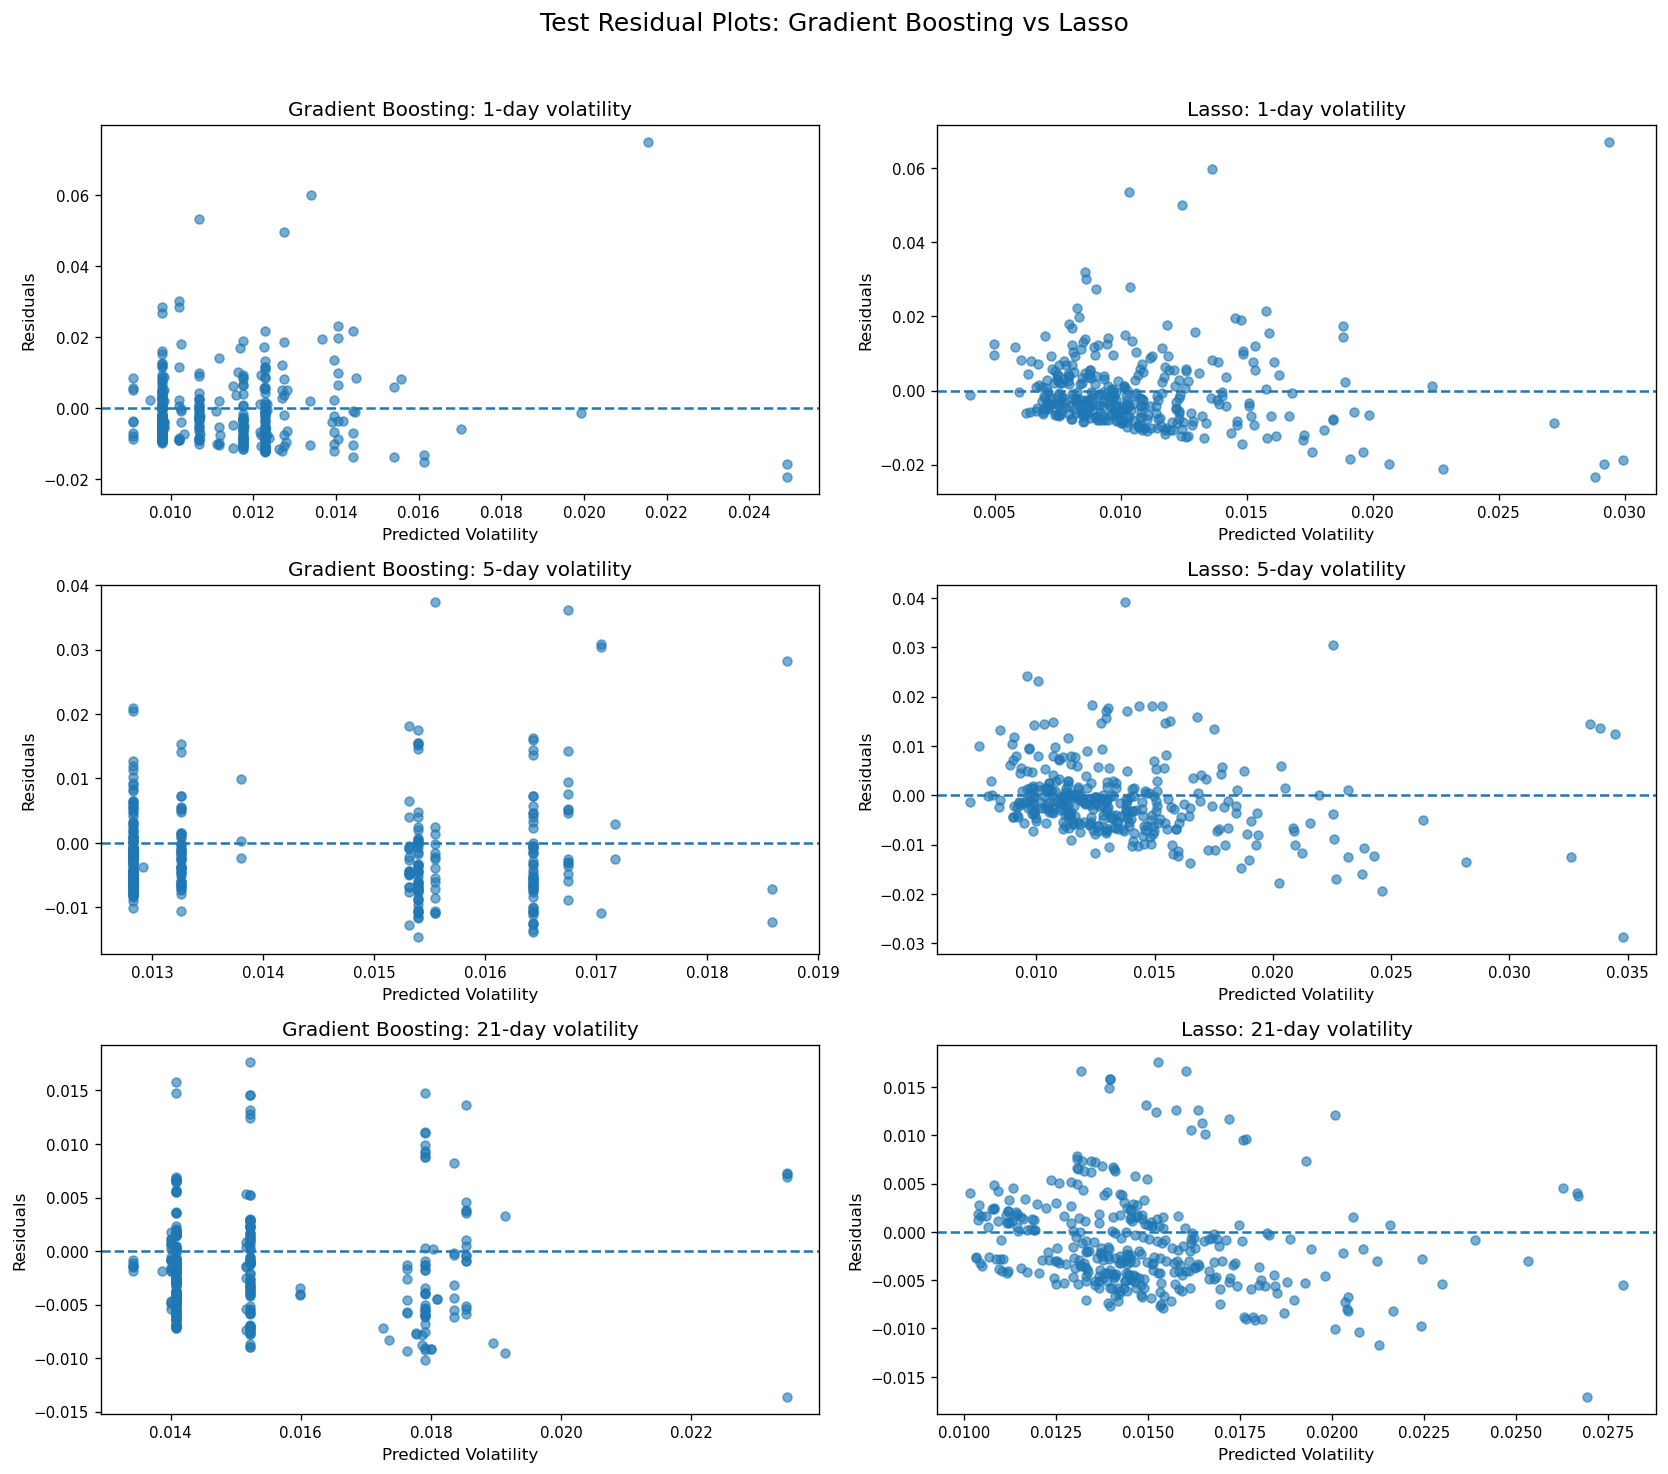

In [83]:
# Test Visualization Results
# Residual Plots

test_targets_only = {
    "1-day volatility": y_test_1d,
    "5-day volatility": y_test_5d,
    "21-day volatility": y_test_21d
}

test_residuals = plot_residuals_side_by_side(
    left_models=best_gb_models,
    right_models=best_lasso_models,
    targets=test_targets_only,
    X_test_final=X_test_scaled,
    left_model_name="Gradient Boosting",
    right_model_name="Lasso",
    dataset_name="Test"
)

### Visualization for Residual plots

The residual plots show that most of the prediction errors are close to zero, which means the models are not always overpredicting or always underpredicting during normal market periods. However, there are still some large positive residuals, especially for the 1-day and 5-day targets. This means the models often underestimate sudden volatility spikes.

Compared with the 1-day target, the 21-day residuals are more tightly grouped and have a smaller range. This suggests that monthly volatility is smoother and easier to predict. Overall, the residual plots show that the models can capture the general volatility level, but they still struggle when unexpected market shocks or extreme volatility events happen.

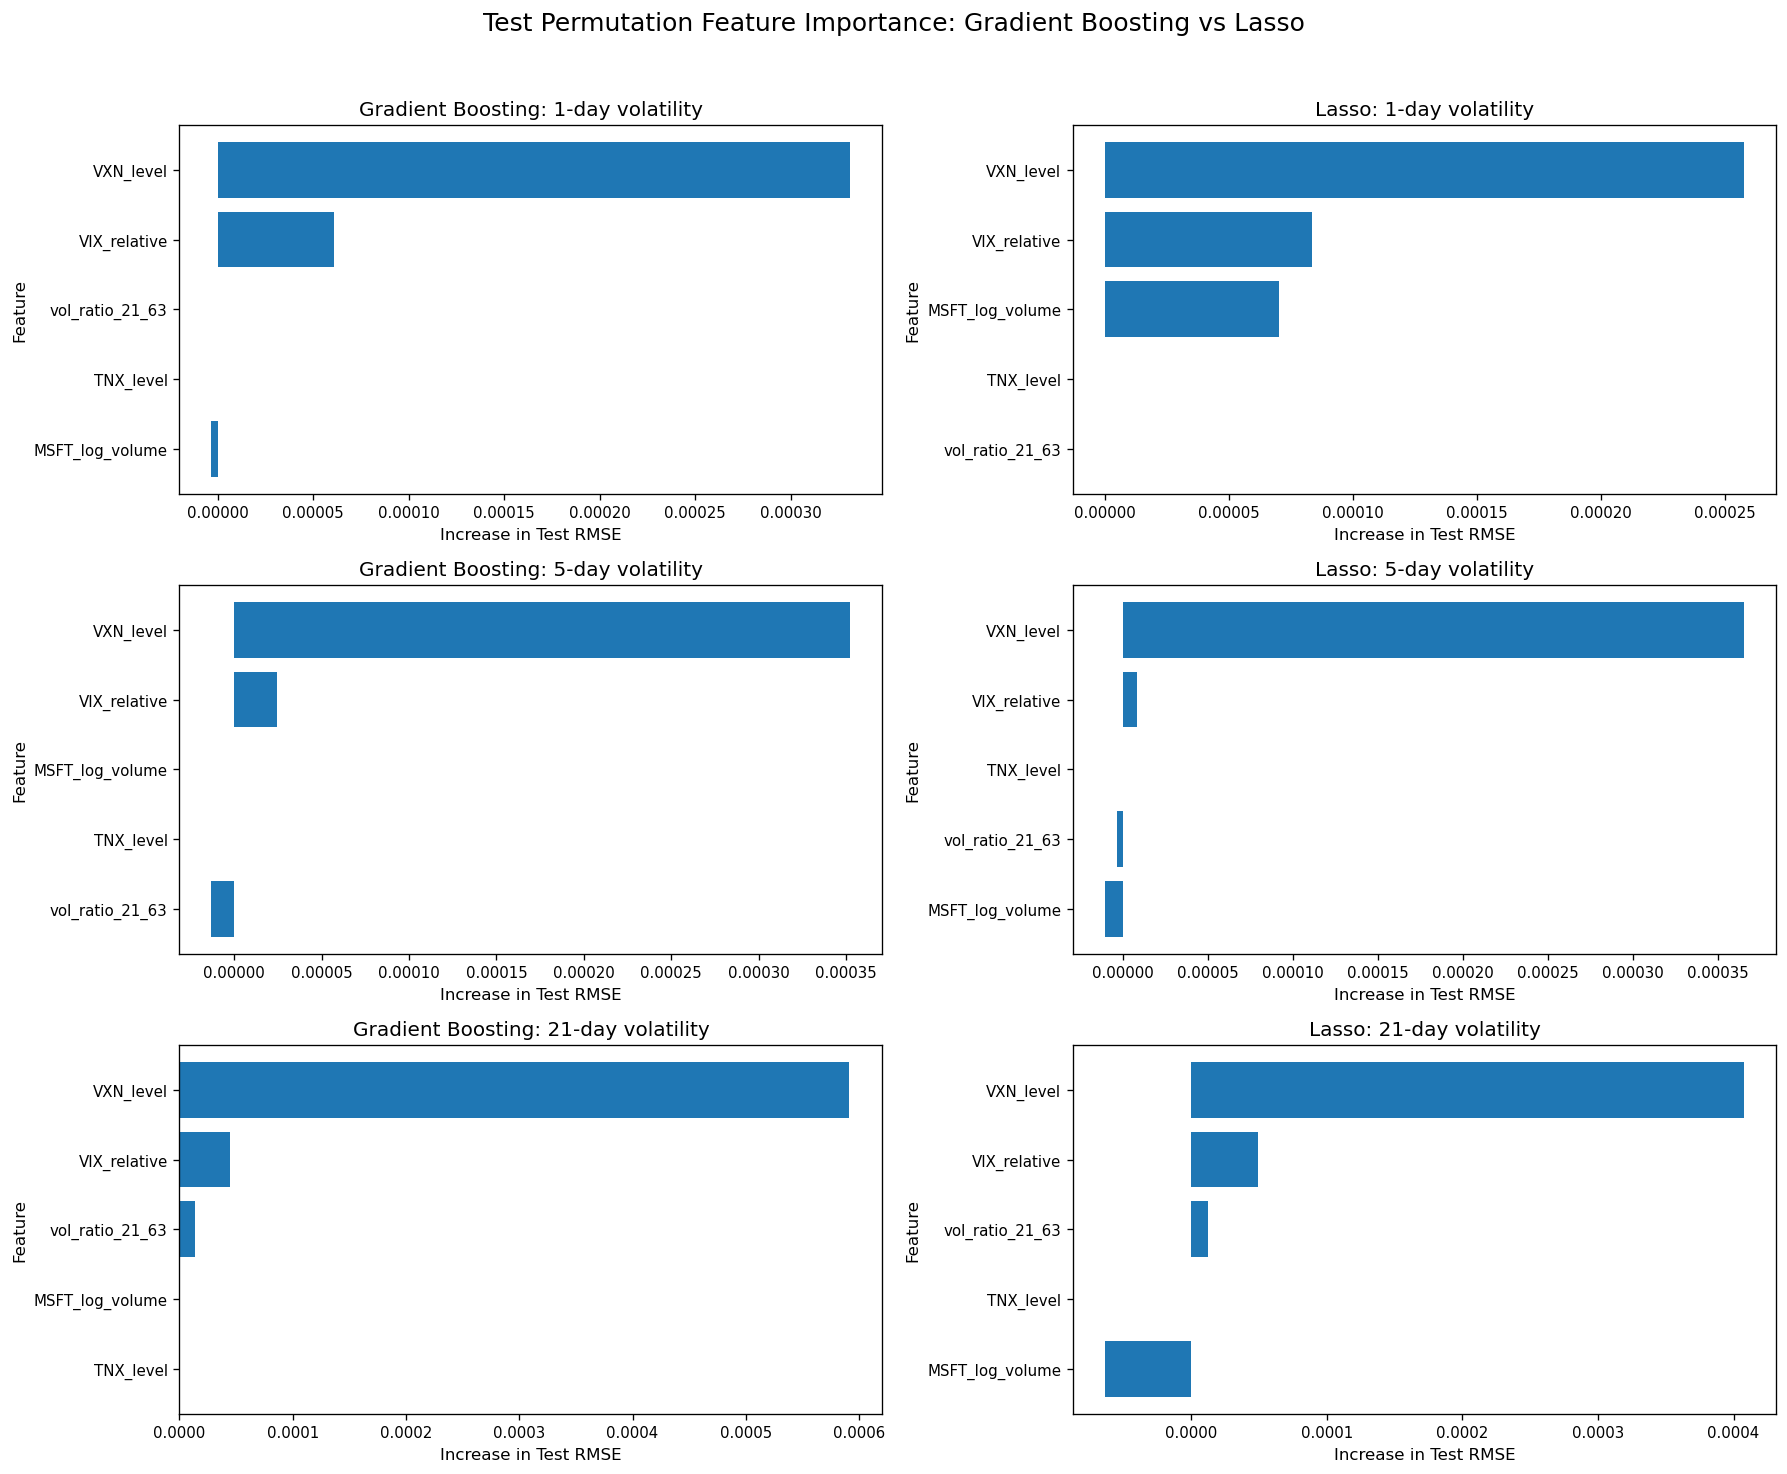

In [84]:
# Test Visualization Results
# Permutation Feature Importance Plots

test_importance = plot_importance_side_by_side(
    left_models=best_gb_models,
    right_models=best_lasso_models,
    targets=test_targets_only,
    X_test_final=X_test_scaled,
    final_feature_cols=top5_features,
    left_model_name="Gradient Boosting",
    right_model_name="Lasso",
    top_n=5,
    dataset_name="Test"
)

### Visualization for Feature Importance

The feature importance results show that VXN_level is the most important predictor for both models and for all three volatility horizons. This means MSFT volatility is closely related to uncertainty in the broader technology market. Since Microsoft is a large tech company, it makes sense that Nasdaq or tech-sector volatility helps predict MSFT’s future volatility.

Other useful features include VIX_relative and vol_ratio_21_63. VIX_relative reflects broader market risk sentiment, while vol_ratio_21_63 shows how short-term volatility compares with longer-term volatility. This suggests that the models are using both current market uncertainty and changes in the volatility environment to make predictions.

Some features, such as **MSFT_log_volume** and **TNX_level**, are less important in some horizons, so they do not consistently help the prediction. Overall, the results show that market-wide and technology-sector volatility measures are the most useful predictors for MSFT volatility.

# 6. Discussions and Conclusions

## Main Conclusion
Based on the test results, we select **Lasso with the 5-day volatility target** as our main model. We focus on the weekly horizon because it provides a good balance between predictability and practical usefulness: it is less noisy than 1-day volatility, but still more actionable than 21-day volatility for short-term risk management. In the Lasso test summary table, the 5-day target has a test RMSE of 0.0075, a positive test R² of 0.0521, and an improvement over the baseline of 0.0657. The actual-versus-predicted plot also shows that the Lasso model captures the general medium-term movement of volatility, even though it does not perfectly match every spike. The residual plots show that most errors are centered around zero, suggesting that the model is not systematically overpredicting or underpredicting most of the time.

Lasso performs well because it is a regularized linear model, which is useful when we have many related financial predictors. Since many volatility-related features are correlated, Lasso helps reduce overfitting by shrinking less useful coefficients and focusing on the strongest signals. The permutation feature importance plots show that variables such as VXN_level, VIX-related measures, and volatility ratio features are important predictors. This makes financial sense because MSFT is a large technology stock, so its volatility is closely related to broader technology-sector uncertainty and market-wide risk sentiment. In practice, a 5-day volatility forecast can help with short-term hedging, position sizing, and monitoring changes in market risk.

The main limitation is that the model still struggles to predict sudden volatility spikes. These spikes may be caused by unexpected earnings news, macroeconomic announcements, firm-specific events, or market shocks that are not fully captured by historical price and volatility features. Overall, the main finding is that **weekly MSFT volatility is partially predictable, and Lasso provides the most useful weekly forecasting model in this study**. The major takeaway is that market and technology-sector volatility indicators contain valuable information for predicting MSFT risk, but volatility forecasting remains difficult. Future work could add richer firm-specific variables, such as earnings surprise, option-implied volatility, analyst revisions, news sentiment, or more detailed event-based features around MSFT earnings announcements.

## Additional information (feature selection process)
Stock volatility is difficult to predict because it can be influenced by many factors, such as market movements, company news, and unexpected events. In our project, we tried several versions of feature sets to see whether adding more information could improve the prediction of MSFT volatility. Through this process, we found that more features did not always lead to better results. Below, we describe the four versions we tested and explain why we selected the third version as our final approach.

### Version 1

In the first version, we used a group of basic financial features to predict MSFT volatility, including MSFT daily returns, lagged returns, rolling volatility, log volume, SPY, QQQ, VIX, and XLK-related features. After training different models, we found that the prediction results were not very good. Many test $R^2$ values were even negative. From the prediction plots, we also noticed that the Gradient Boosting model failed to capture large volatility spikes. Because of this, we thought these spikes might be caused by sudden market events, MSFT-related news, or geopolitical factors that are hard to predict using only historical price-based features.

### Version 2

For the second version, we tried to improve the model by adding more features. We kept the original features and added longer-term MSFT volatility, TNX, SOXX, TLT, volume ratio, volatility ratios, VIX relative level, MSFT beta with SPY, MSFT idiosyncratic return and volatility, and earnings-related variables. However, the results still did not improve much. Many $R^2$ values were still negative, and the MAE did not clearly decrease. This made us think that adding more features was not necessarily helpful. We think some features are highly correlated with each other, which may increase the risk of overfitting.

### Version 3

To deal with the problem of too many features, we used Lasso regression for feature selection. Since Lasso can shrink some coefficients to zero, it helped us choose five non-zero features: VXN_level, vol_ratio_21_63, VIX_relative, MSFT_log_volume, and TNX_level. Then, the results improved compared with the earlier versions. This suggests that a smaller feature set may work better than adding many correlated features.

### Version 4

After that, we still wanted to test whether MSFT-specific events could help the prediction, so we added the earnings-related features back into the model, including days to earnings. However, these features did not improve the results. The model even performed slightly worse than Version 3. Therefore, we decided to use Version 3 as our final version.

# Appendix. Reproducibility

- State the software environment.
- State package versions if relevant.
- Explain how to reproduce the analysis.
- Ensure the notebook has been run from start to finish.


In [ ]:
# example: package versions
# import sys
# print(sys.version)
# print(pd.__version__)
# print(np.__version__)

# References

- Include all papers, datasets, websites, and software packages cited in the notebook.
- Use a consistent citation style.
